In [1]:
# ===== Standard Library =====
import os
from pathlib import Path

# ===== Third-party Libraries =====
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda x: '%.5f' % x)

In [2]:
# Change working directory to project root
PROJECT_ROOT = Path().absolute().parent if Path().absolute().name == 'processors' else Path().absolute()
os.chdir(PROJECT_ROOT)
!pwd

/Users/phatvu/Documents/Dev-Drive-Local/crypto-price-forecaster-glm


In [3]:
# Import project configuration
import sys
sys.path.append('.')
from config import *

In [4]:
EPS = 1e-8

In [5]:
master_dataset_path = Path(get_cleaned_dataset_file())
master_df = pd.read_pickle(master_dataset_path)
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17059 entries, 0 to 17058
Data columns (total 74 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   timestamp                           17059 non-null  object 
 1   BTC_open                            17059 non-null  float64
 2   BTC_high                            17059 non-null  float64
 3   BTC_low                             17059 non-null  float64
 4   BTC_close                           17059 non-null  float64
 5   BTC_volume                          17059 non-null  float64
 6   BTC_quote_volume                    17059 non-null  float64
 7   BTC_trades                          17059 non-null  float64
 8   ETH_open                            17059 non-null  float64
 9   ETH_high                            17059 non-null  float64
 10  ETH_low                             17059 non-null  float64
 11  ETH_close                           17059

## OHLCV

### Build Target

In [6]:
master_df['timestamp'] = pd.to_datetime(master_df['timestamp'])
master_df = master_df.sort_values('timestamp').reset_index(drop=True)
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17059 entries, 0 to 17058
Data columns (total 74 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   timestamp                           17059 non-null  datetime64[ns]
 1   BTC_open                            17059 non-null  float64       
 2   BTC_high                            17059 non-null  float64       
 3   BTC_low                             17059 non-null  float64       
 4   BTC_close                           17059 non-null  float64       
 5   BTC_volume                          17059 non-null  float64       
 6   BTC_quote_volume                    17059 non-null  float64       
 7   BTC_trades                          17059 non-null  float64       
 8   ETH_open                            17059 non-null  float64       
 9   ETH_high                            17059 non-null  float64       
 10  ETH_low               

In [7]:
print("Before log return calculation:", master_df.shape)
master_df['BTC_log_return'] = np.log(master_df['BTC_close'] / master_df['BTC_close'].shift(1))
master_df['ETH_log_return'] = np.log(master_df['ETH_close'] / master_df['ETH_close'].shift(1))
master_df.dropna(subset=['BTC_log_return', 'ETH_log_return'], inplace=True)
print("After log return calculation:", master_df.shape)

Before log return calculation: (17059, 74)
After log return calculation: (17058, 76)


#### Stationarity Check

In [8]:
def adf_plot(series, name, ax, alpha=0.05):
    result = adfuller(series.dropna())
    stat, pval = result[0], result[1]
    series.plot(ax=ax, title=f"{name}")
    ax.axhline(0, color="gray", lw=1, ls="--")
    txt = f"ADF: {stat:.2f}\np-value: {pval:.2g}"
    ax.text(0.86, 0.03, txt, transform=ax.transAxes, va="bottom",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
    return pval < alpha

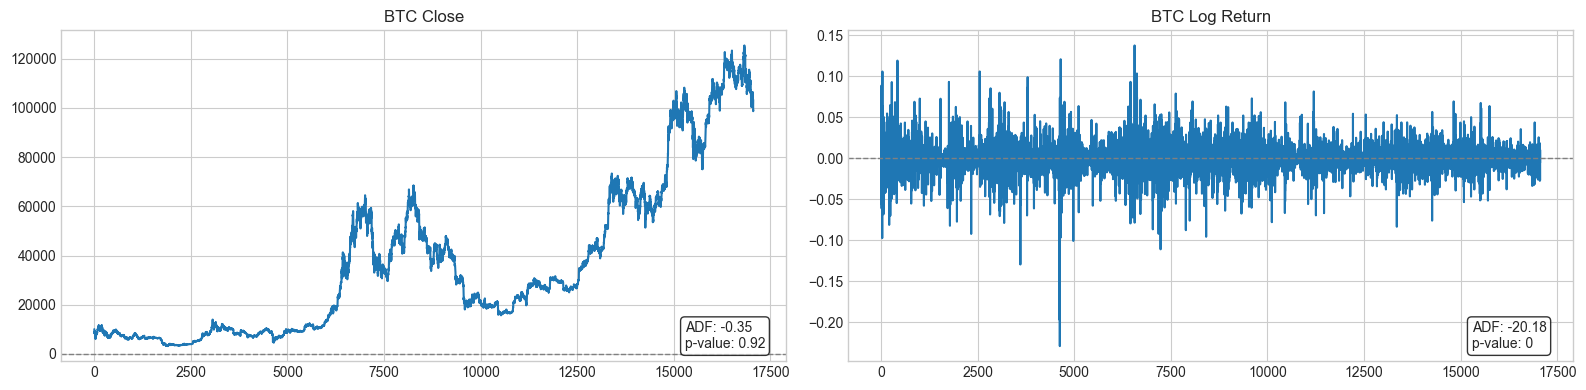

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharex=False)
price_stationary_BTC = adf_plot(master_df['BTC_close'], "BTC Close", axes[0])
return_stationary_BTC = adf_plot(master_df['BTC_log_return'], "BTC Log Return", axes[1])
plt.tight_layout()
plt.show()

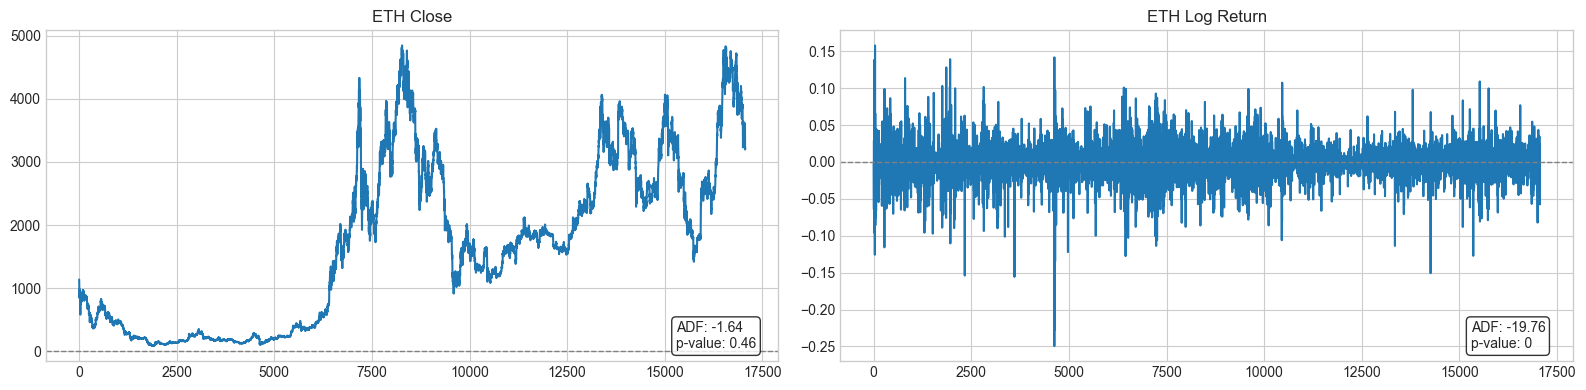

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharex=False)
price_stationary_ETH = adf_plot(master_df['ETH_close'], "ETH Close", axes[0])
return_stationary_ETH = adf_plot(master_df['ETH_log_return'], "ETH Log Return", axes[1])
plt.tight_layout()
plt.show()

#### Distribution

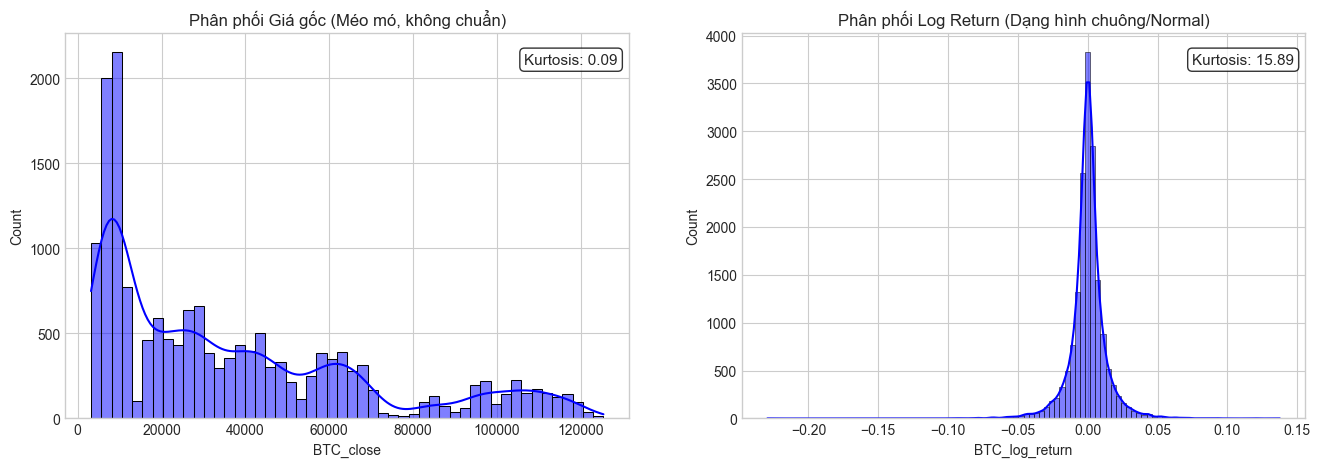

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

k_close = master_df['BTC_close'].kurtosis()
k_log_return = master_df['BTC_log_return'].kurtosis()

# Raw Price Dist
sns.histplot(master_df['BTC_close'], bins=50, kde=True, ax=ax[0], color='blue')
ax[0].set_title('Phân phối Giá gốc (Méo mó, không chuẩn)')
ax[0].text(0.98, 0.95, f"Kurtosis: {k_close:.2f}", transform=ax[0].transAxes,
           ha="right", va="top", fontsize=11, bbox=dict(boxstyle="round", fc="white", alpha=0.8))

# Log Return Dist
sns.histplot(master_df['BTC_log_return'], bins=100, kde=True, ax=ax[1], color='blue')
ax[1].set_title('Phân phối Log Return (Dạng hình chuông/Normal)')
ax[1].text(0.98, 0.95, f"Kurtosis: {k_log_return:.2f}", transform=ax[1].transAxes,
           ha="right", va="top", fontsize=11, bbox=dict(boxstyle="round", fc="white", alpha=0.8))
plt.show()

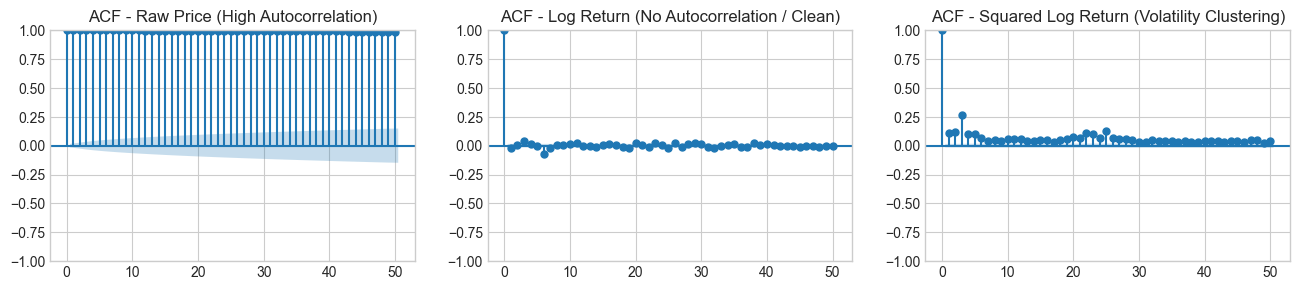

In [12]:
fig, ax = plt.subplots(1, 3, figsize=(16, 3))

# ACF Raw Price
plot_acf(master_df['BTC_close'], lags=50, ax=ax[0], title='ACF - Raw Price (High Autocorrelation)')

# ACF Log Return
plot_acf(master_df['BTC_log_return'], lags=50, ax=ax[1], title='ACF - Log Return (No Autocorrelation / Clean)')

# ACF Squared Log Return
plot_acf(master_df['BTC_log_return']**2, lags=50, ax=ax[2], title='ACF - Squared Log Return (Volatility Clustering)')

plt.show()

In [13]:
# build target
print("Before target creation:", master_df.shape)
master_df['target'] = master_df['BTC_log_return'].shift(-1)
master_df.dropna(subset=['target'], inplace=True)
print("After target creation:", master_df.shape)

Before target creation: (17058, 76)
After target creation: (17057, 77)


### Volume

In [14]:
# Volume log-return (Momentum Volume)
master_df['log_volume'] = np.log1p(master_df['BTC_volume'])

master_df['BTC_vol_log_return'] = (
    master_df['log_volume'] - 
    master_df['log_volume'].shift(1)
)

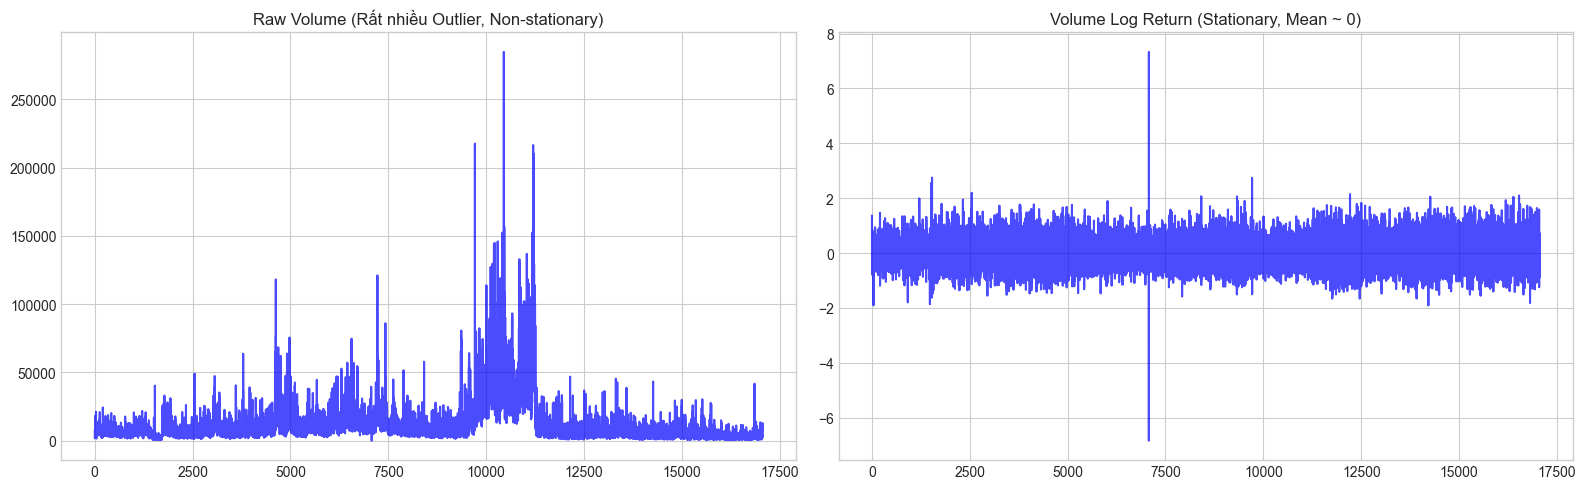

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

ax[0].plot(master_df.index, master_df['BTC_volume'], color='blue', alpha=0.7)
ax[0].set_title('Raw Volume (Rất nhiều Outlier, Non-stationary)')

ax[1].plot(master_df.index, master_df['BTC_vol_log_return'], color='blue', alpha=0.7)
ax[1].set_title('Volume Log Return (Stationary, Mean ~ 0)')

plt.tight_layout()
plt.show()

In [16]:
master_df['vol_ma20'] = (
    master_df['BTC_volume']
    .rolling(20)
    .mean()
    .shift(1) 
)

master_df['rvol'] = master_df['BTC_volume'] / (master_df['vol_ma20'] + EPS)
master_df['log_rvol'] = np.log(master_df['rvol'] + EPS)

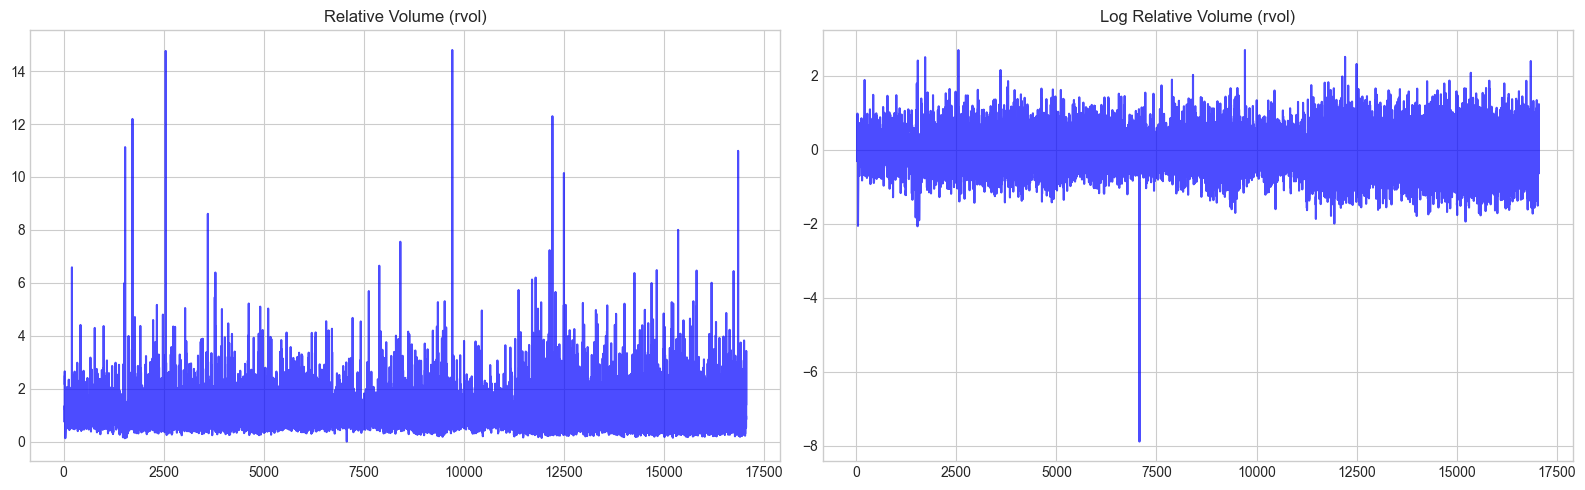

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

ax[0].plot(master_df.index, master_df['rvol'], color='blue', alpha=0.7)
ax[0].set_title('Relative Volume (rvol)')

ax[1].plot(master_df.index, master_df['log_rvol'], color='blue', alpha=0.7)
ax[1].set_title('Log Relative Volume (rvol)')

plt.tight_layout()
plt.show()

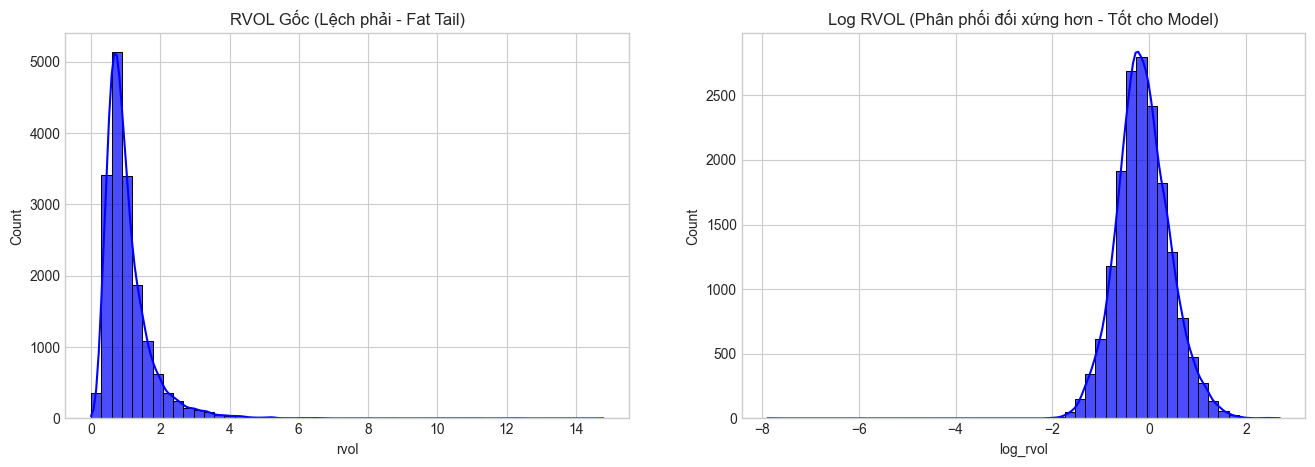

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(master_df['rvol'], bins=50, kde=True, ax=ax[0], color='blue', alpha=0.7)
ax[0].set_title('RVOL Gốc (Lệch phải - Fat Tail)')

sns.histplot(master_df['log_rvol'], bins=50, kde=True, ax=ax[1], color='blue', alpha=0.7)
ax[1].set_title('Log RVOL (Phân phối đối xứng hơn - Tốt cho Model)')

plt.show()

### Volality

In [19]:
# Standard Deviation
master_df['vol_std_20'] = master_df['BTC_log_return'].rolling(20).std()

# Parkinson (High-Low)
const_pk = 1.0 / (4.0 * np.log(2.0))
rv_pk = const_pk * (np.log(master_df['BTC_high'] / master_df['BTC_low'])**2)
master_df['vol_pk'] = np.sqrt(rv_pk)

# Garman-Klass (OHLC)
log_hl = np.log(master_df['BTC_high'] / master_df['BTC_low'])**2
log_co = np.log(master_df['BTC_close'] / master_df['BTC_open'])**2
rv_gk = 0.5 * log_hl - (2 * np.log(2) - 1) * log_co
master_df['vol_gk'] = np.sqrt(np.maximum(rv_gk, 0))

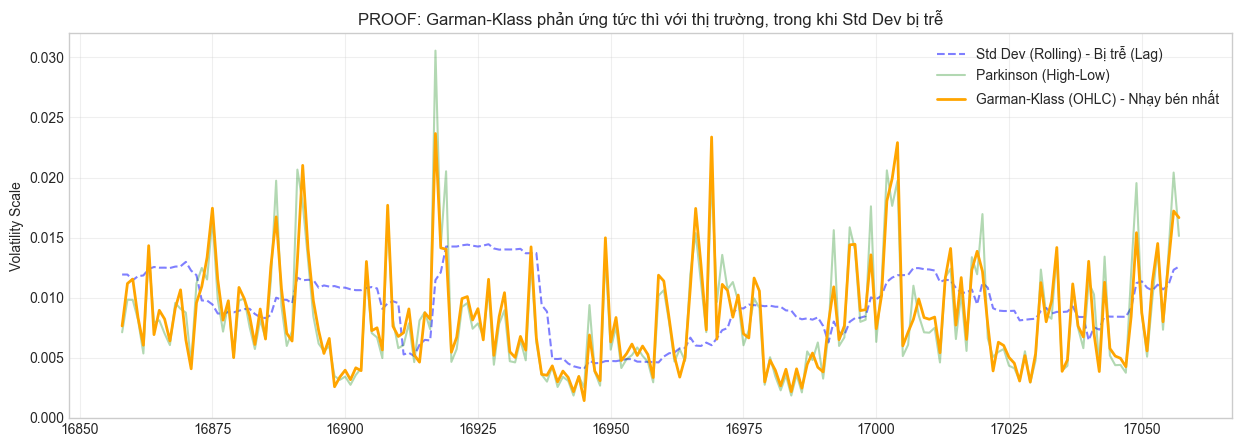

In [20]:
subset = master_df.iloc[-200:].copy()

plt.figure(figsize=(15, 5))
plt.plot(subset.index, subset['vol_std_20'], label='Std Dev (Rolling) - Bị trễ (Lag)', color='blue', linestyle='--', alpha=0.5)
plt.plot(subset.index, subset['vol_pk'], label='Parkinson (High-Low)', color='green', alpha=0.3)
plt.plot(subset.index, subset['vol_gk'], label='Garman-Klass (OHLC) - Nhạy bén nhất', color='orange', linewidth=2)
plt.title('PROOF: Garman-Klass phản ứng tức thì với thị trường, trong khi Std Dev bị trễ')
plt.ylabel('Volatility Scale')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [21]:
# Volatility Surprise
roll_mean_50 = master_df['vol_gk'].rolling(50).mean().shift(1)
roll_std_50  = master_df['vol_gk'].rolling(50).std().shift(1)
master_df['vol_gk_z'] = (master_df['vol_gk'] - roll_mean_50) / (roll_std_50 + EPS)

# Signed Volatility
master_df['vol_signed'] = master_df['vol_gk'] * np.sign(master_df['BTC_log_return'])

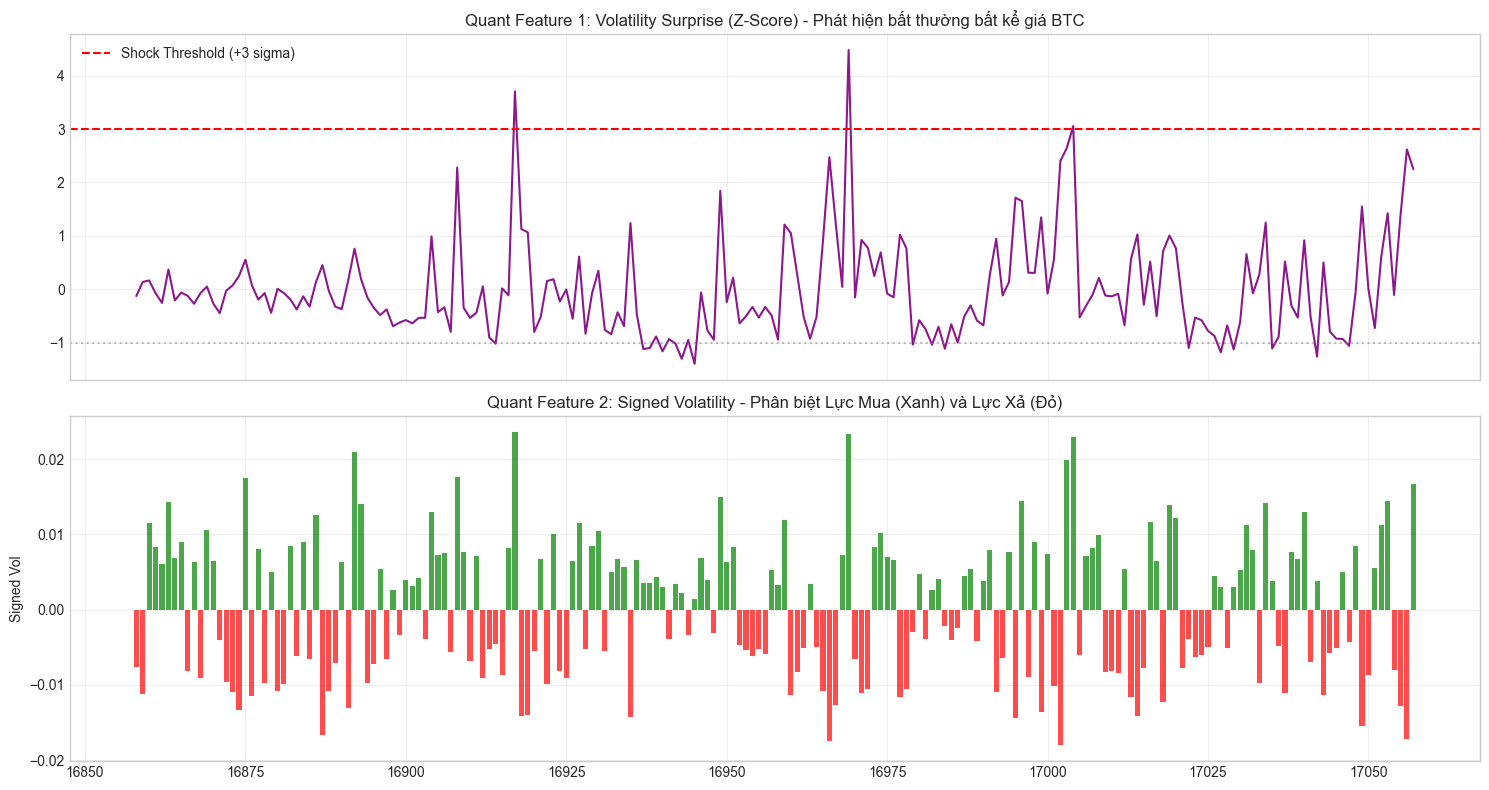

In [22]:
subset = master_df.iloc[-200:].copy()

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

# Feature 1: Z-Score
axes[0].plot(subset.index, subset['vol_gk_z'], color='purple', alpha=0.9)
axes[0].axhline(3, color='red', ls='--', label='Shock Threshold (+3 sigma)')
axes[0].axhline(-1, color='gray', ls=':', alpha=0.5)
axes[0].set_title('Quant Feature 1: Volatility Surprise (Z-Score) - Phát hiện bất thường bất kể giá BTC')
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

# Feature 2: Signed Volatility
colors = np.where(subset['vol_signed'] >= 0, 'green', 'red')
axes[1].bar(subset.index, subset['vol_signed'], color=colors, alpha=0.7)
axes[1].set_title('Quant Feature 2: Signed Volatility - Phân biệt Lực Mua (Xanh) và Lực Xả (Đỏ)')
axes[1].set_ylabel('Signed Vol')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
# cleanup: master_df.drop(columns=['vol_std_20', 'vol_pk'], inplace=True)

### Microstructure features - Candelstick dynamics

In [24]:
range = master_df['BTC_high'] - master_df['BTC_low']
body = np.abs(master_df['BTC_close'] - master_df['BTC_open'])
upper_wick = master_df['BTC_high'] - np.maximum(master_df['BTC_close'], master_df['BTC_open'])
lower_wick = np.minimum(master_df['BTC_close'], master_df['BTC_open']) - master_df['BTC_low']

In [25]:
# Close location value (clv))
master_df['clv'] = np.where(
    range > EPS,
    ((master_df['BTC_close'] - master_df['BTC_low']) - (master_df['BTC_high'] - master_df['BTC_close'])) / range,
    0.0
)

In [26]:
# Shadow ratios
master_df['upper_wick_ratio'] = upper_wick / (range + EPS)
master_df['lower_wick_ratio'] = lower_wick / (range + EPS)

# Wick Imbalance
master_df['wick_imbalance'] = (upper_wick - lower_wick) / (range + EPS)

/var/folders/h3/4_pq_7pd3pq2286xkp78c1480000gn/T/ipykernel_32734/4113391469.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=master_df, x='clv_bin', y='debug_next_return', palette='RdYlGn', errorbar=None)


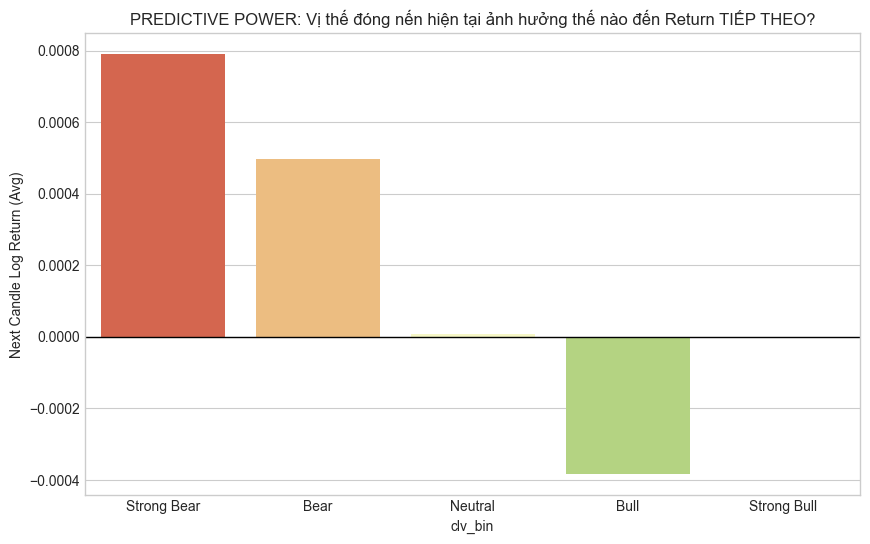

In [27]:
master_df['debug_next_return'] = master_df['BTC_log_return'].shift(-1)

master_df['clv_bin'] = pd.cut(master_df['clv'], bins=5, labels=['Strong Bear', 'Bear', 'Neutral', 'Bull', 'Strong Bull'])

plt.figure(figsize=(10, 6))
sns.barplot(data=master_df, x='clv_bin', y='debug_next_return', palette='RdYlGn', errorbar=None)
plt.axhline(0, color='black', lw=1)
plt.title('PREDICTIVE POWER: Vị thế đóng nến hiện tại ảnh hưởng thế nào đến Return TIẾP THEO?')
plt.ylabel('Next Candle Log Return (Avg)')
plt.show()

master_df.drop(columns=['debug_next_return', 'clv_bin'], inplace=True)

### Technical indicators

In [28]:
window = 20

ma20_shifted  = master_df['BTC_close'].rolling(window).mean().shift(1)
std20_shifted = master_df['BTC_close'].rolling(window).std().shift(1)

master_df['bb_upper'] = ma20_shifted + 2 * std20_shifted
master_df['bb_lower'] = ma20_shifted - 2 * std20_shifted

In [29]:
master_df['bb_pct_b'] = (master_df['BTC_close'] - master_df['bb_lower']) / ((master_df['bb_upper'] - master_df['bb_lower']) + EPS)
master_df['bb_width'] = (master_df['bb_upper'] - master_df['bb_lower']) / (ma20_shifted + EPS)

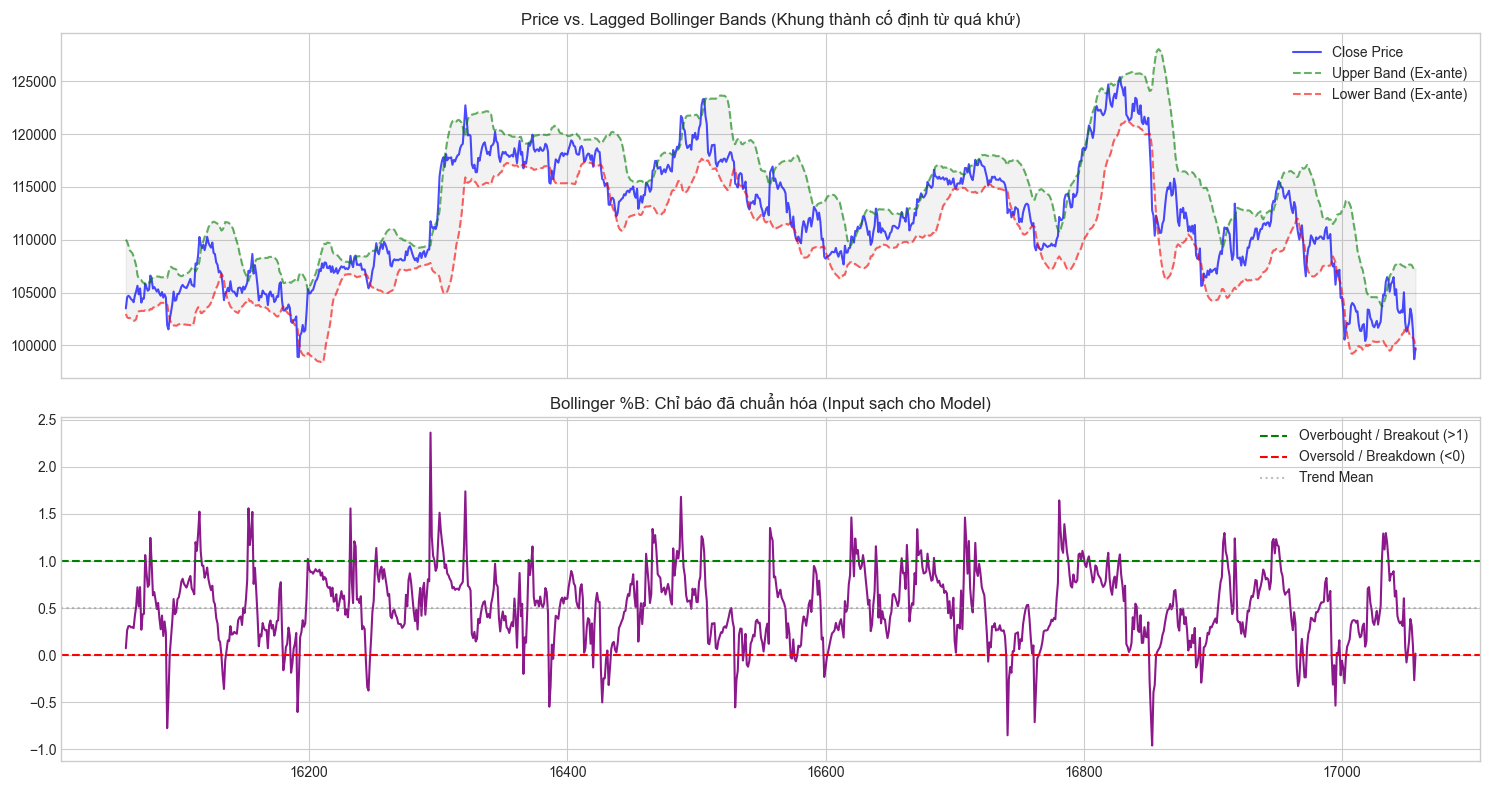

In [30]:
subset = master_df.iloc[-1000:].copy()

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

# Hình 1: Giá và Bands (Đã shift)
# Bạn sẽ thấy đôi khi giá vọt ra ngoài Band rõ ràng hơn cách cũ
axes[0].plot(subset.index, subset['BTC_close'], label='Close Price', color='blue', alpha=0.7)
axes[0].plot(subset.index, subset['bb_upper'], color='green', linestyle='--', alpha=0.6, label='Upper Band (Ex-ante)')
axes[0].plot(subset.index, subset['bb_lower'], color='red', linestyle='--', alpha=0.6, label='Lower Band (Ex-ante)')
axes[0].fill_between(subset.index, subset['bb_upper'], subset['bb_lower'], color='gray', alpha=0.1) # Tô màu nền cho đẹp
axes[0].set_title('Price vs. Lagged Bollinger Bands (Khung thành cố định từ quá khứ)')
axes[0].legend()

# Hình 2: %B (Stationary)
axes[1].plot(subset.index, subset['bb_pct_b'], color='purple', alpha=0.9)
# Vẽ các đường ranh giới quan trọng
axes[1].axhline(1, color='green', ls='--', label='Overbought / Breakout (>1)')
axes[1].axhline(0, color='red', ls='--', label='Oversold / Breakdown (<0)')
axes[1].axhline(0.5, color='gray', ls=':', alpha=0.5, label='Trend Mean')
axes[1].set_title('Bollinger %B: Chỉ báo đã chuẩn hóa (Input sạch cho Model)')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()



In [31]:
# # Clean up các cột trung gian không cần thiết cho Model (giữ lại bb_pct_b và bb_width)
# master_df.drop(columns=['bb_upper', 'bb_lower'], inplace=True)

### Inter-market correlation

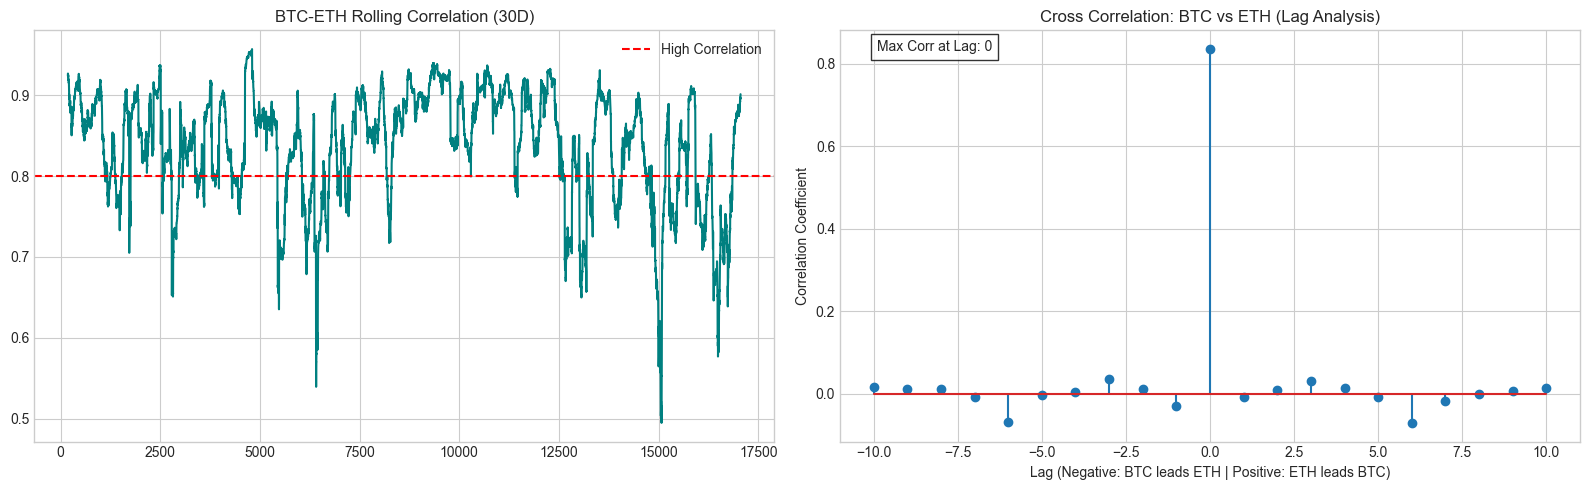

In [32]:
# CELL 6: INTER-MARKET CORRELATION (BTC vs ETH)
# ---------------------------------------------------

# 1. Rolling Correlation (Biến động theo thời gian)
# Đo lường mức độ "Đồng pha" của thị trường
window = 30 * 6 # 30 ngày (với nến 4H)
master_df['btc_eth_corr'] = master_df['BTC_log_return'].rolling(window).corr(master_df['ETH_log_return'])

# 2. Lead-Lag Cross Correlation (Ai chạy trước?)
lags = np.arange(-10, 11)
ccov = []

# Loop tính correlation từng lag một cách an toàn
x = master_df['BTC_log_return']
y = master_df['ETH_log_return']

for l in lags:
    # Shift chuỗi y (ETH) đi l đơn vị
    y_shifted = y.shift(l)
    
    # Chỉ lấy các index mà cả x và y_shifted đều không phải NaN
    valid_mask = x.notna() & y_shifted.notna()
    
    if valid_mask.sum() > 100: # Đảm bảo đủ dữ liệu
        c = x[valid_mask].corr(y_shifted[valid_mask])
        ccov.append(c)
    else:
        ccov.append(np.nan)

# --- VISUALIZE ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Rolling Correlation
axes[0].plot(master_df.index, master_df['btc_eth_corr'], color='teal')
axes[0].axhline(0.8, color='red', ls='--', label='High Correlation')
axes[0].set_title('BTC-ETH Rolling Correlation (30D)')
axes[0].legend()

# Plot 2: Cross Correlation
axes[1].stem(lags, ccov)
axes[1].set_title('Cross Correlation: BTC vs ETH (Lag Analysis)')
axes[1].set_xlabel('Lag (Negative: BTC leads ETH | Positive: ETH leads BTC)')
axes[1].set_ylabel('Correlation Coefficient')

# Tìm Lag có tương quan cao nhất
max_corr_idx = np.argmax(ccov)
best_lag = lags[max_corr_idx]
axes[1].text(0.05, 0.95, f"Max Corr at Lag: {best_lag}", transform=axes[1].transAxes, 
             bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

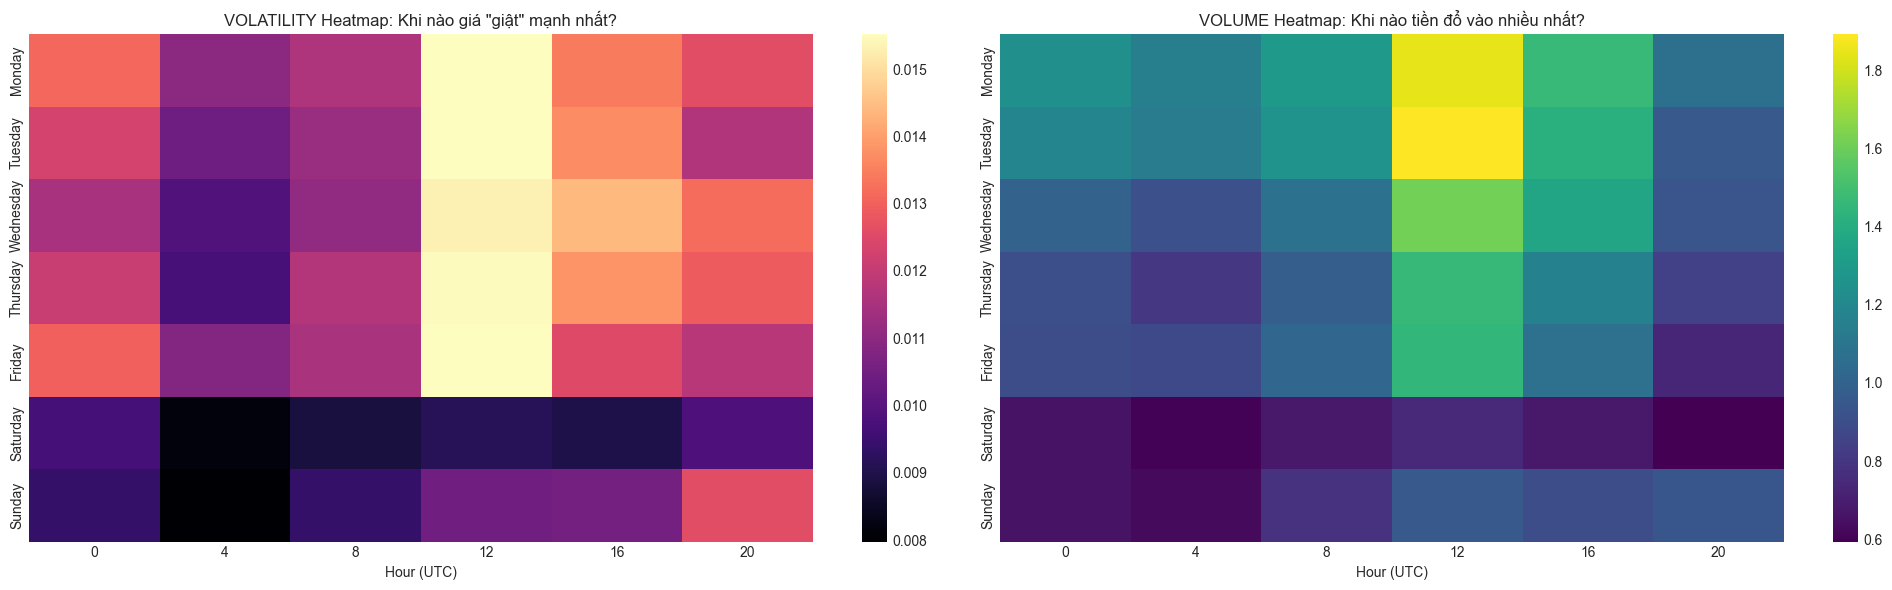

In [33]:
# CELL 7: SEASONALITY & TIME ENCODING
# ---------------------------------------------------

# 1. FEATURE ENGINEERING: CYCLIC TIME ENCODING
# Model máy học không hiểu tính chu kỳ (VD: 23h và 0h là sát nhau).
# Sin/Cos giúp biến thời gian thành vòng tròn khép kín.
import numpy as np

# Sử dụng cột timestamp thay vì index
# Lưu ý: master_df['timestamp'] phải là dạng datetime rồi
master_df['hour_sin'] = np.sin(2 * np.pi * master_df['timestamp'].dt.hour / 24)
master_df['hour_cos'] = np.cos(2 * np.pi * master_df['timestamp'].dt.hour / 24)

master_df['day_sin'] = np.sin(2 * np.pi * master_df['timestamp'].dt.dayofweek / 7)
master_df['day_cos'] = np.cos(2 * np.pi * master_df['timestamp'].dt.dayofweek / 7)


# 2. EDA: HEATMAP (TÌM "GIỜ VÀNG" CỦA THỊ TRƯỜNG)
# Chuẩn bị dữ liệu phụ trợ để vẽ (sẽ xóa sau)
master_df['weekday_name'] = master_df['timestamp'].dt.day_name()
master_df['hour_num'] = master_df['timestamp'].dt.hour
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Pivot Table 1: Volatility (Dùng Garman-Klass 'vol_gk' đã tính ở Cell 3)
pivot_vol = master_df.pivot_table(index='weekday_name', columns='hour_num', values='vol_gk', aggfunc='mean')
pivot_vol = pivot_vol.reindex(days_order)

# Pivot Table 2: Volume (Dùng 'rvol' đã tính ở Cell 1)
pivot_rvol = master_df.pivot_table(index='weekday_name', columns='hour_num', values='rvol', aggfunc='mean')
pivot_rvol = pivot_rvol.reindex(days_order)

# --- VISUALIZE ---
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# Heatmap 1: Biến động (Giá chạy mạnh lúc nào?)
sns.heatmap(pivot_vol, cmap='magma', ax=axes[0], annot=False)
axes[0].set_title('VOLATILITY Heatmap: Khi nào giá "giật" mạnh nhất?')
axes[0].set_ylabel('')
axes[0].set_xlabel('Hour (UTC)')

# Heatmap 2: Khối lượng (Tiền vào lúc nào?)
sns.heatmap(pivot_rvol, cmap='viridis', ax=axes[1], annot=False)
axes[1].set_title('VOLUME Heatmap: Khi nào tiền đổ vào nhiều nhất?')
axes[1].set_ylabel('')
axes[1].set_xlabel('Hour (UTC)')

plt.tight_layout()
plt.show()

# 3. CLEAN UP
# Xóa các cột phụ trợ dùng để vẽ, giữ lại hour_sin/cos, day_sin/cos cho Model
master_df.drop(columns=['weekday_name', 'hour_num'], inplace=True)

In [34]:
from scipy.stats import spearmanr

/var/folders/h3/4_pq_7pd3pq2286xkp78c1480000gn/T/ipykernel_32734/1292395616.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_ic, x='IC_Score', y='Feature', palette=colors)


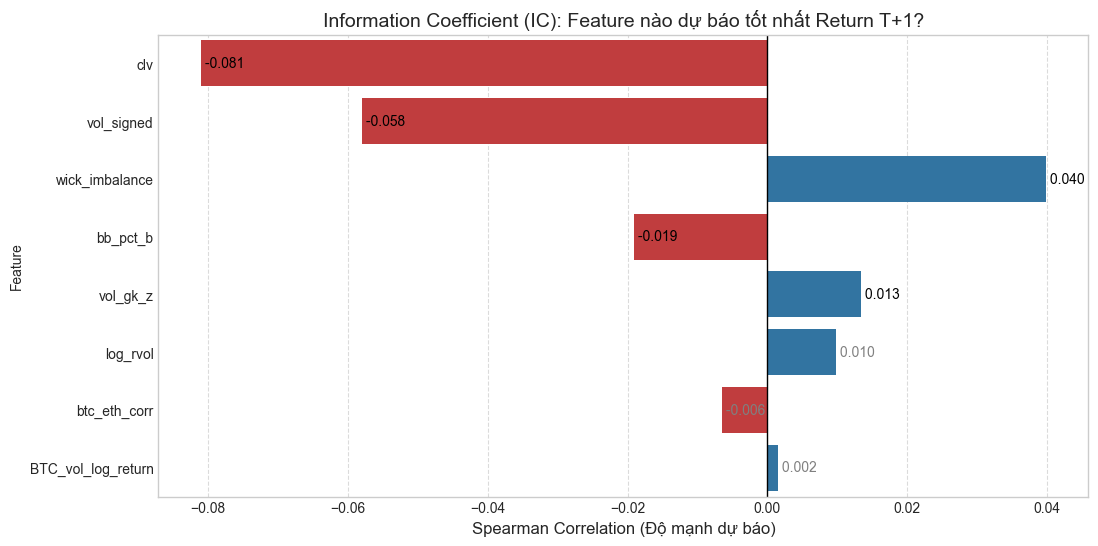

Top features tiềm năng nhất:
              Feature  IC_Score  P-Value
4                 clv  -0.08108  0.00000
1          vol_signed  -0.05800  0.00000
5      wick_imbalance   0.03988  0.00000
6            bb_pct_b  -0.01913  0.01294
0            vol_gk_z   0.01341  0.08158
2            log_rvol   0.00979  0.20345
7        btc_eth_corr  -0.00642  0.40411
3  BTC_vol_log_return   0.00154  0.84119


In [35]:
# %%
# ===== FEATURE IMPORTANCE ANALYSIS =====
from scipy.stats import spearmanr

# 1. Đồng bộ tên biến (Mapping đúng với các bước trên)
features_list = [
    'vol_gk_z',           # Volatility Surprise (Rất hay!)
    'vol_signed',         # Volatility có hướng
    'log_rvol',           # Relative Volume
    'BTC_vol_log_return', # Momentum của Volume
    'clv',                # Vị thế đóng nến
    'wick_imbalance',     # Sự mất cân bằng cung cầu
    'bb_pct_b',           # Vị trí giá so với Bollinger Bands
    'btc_eth_corr'        # Tương quan liên thị trường
]

# 2. Tạo DataFrame sạch để đánh giá (Bỏ NaN)
# Lưu ý: Target là shift(-1) của return hiện tại
eval_df = master_df.copy()
eval_df['NEXT_return'] = eval_df['BTC_log_return'].shift(-1)
eval_df = eval_df.dropna(subset=features_list + ['NEXT_return'])

# 3. Tính IC (Information Coefficient)
ic_scores = []
for feat in features_list:
    # Spearman correlation: Tốt cho quan hệ phi tuyến tính
    corr, pval = spearmanr(eval_df[feat], eval_df['NEXT_return'])
    ic_scores.append({'Feature': feat, 'IC_Score': corr, 'P-Value': pval})

df_ic = pd.DataFrame(ic_scores).sort_values(by='IC_Score', key=abs, ascending=False)

# 4. Visualize chuyên nghiệp hơn
plt.figure(figsize=(12, 6))
# Tô màu: Xanh dương cho tương quan dương, Đỏ cho tương quan âm
colors = ['#1f77b4' if x > 0 else '#d62728' for x in df_ic['IC_Score']]
sns.barplot(data=df_ic, x='IC_Score', y='Feature', palette=colors)

plt.axvline(0, color='black', linewidth=1)
plt.title('Information Coefficient (IC): Feature nào dự báo tốt nhất Return T+1?', fontsize=14)
plt.xlabel('Spearman Correlation (Độ mạnh dự báo)', fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.7)

# Thêm chú thích giá trị
for i, v in enumerate(df_ic['IC_Score']):
    plt.text(v, i, f' {v:.3f}', va='center', fontsize=10, 
             color='black' if abs(v) > 0.01 else 'gray')

plt.show()

print("Top features tiềm năng nhất:")
print(df_ic[['Feature', 'IC_Score', 'P-Value']])

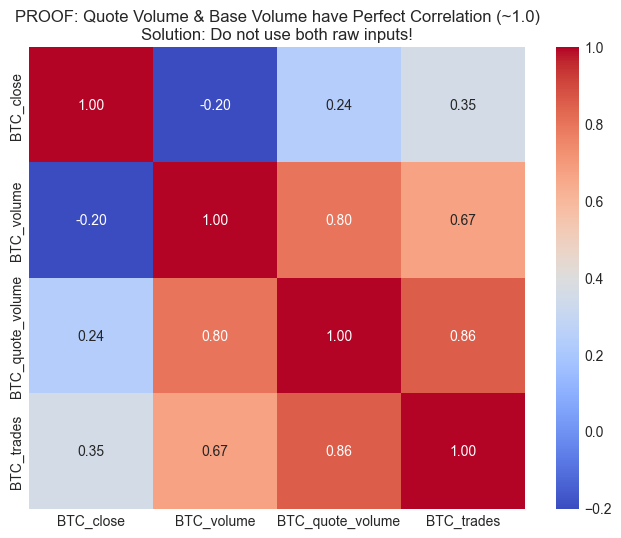

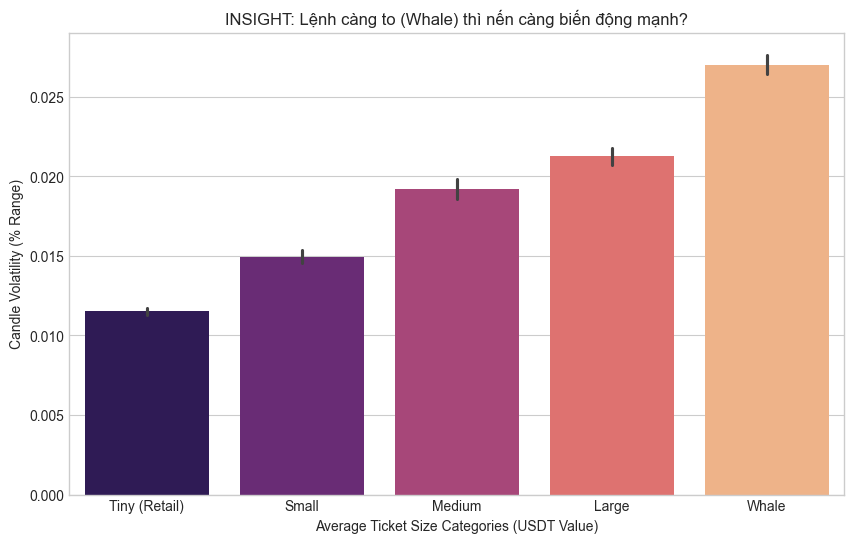

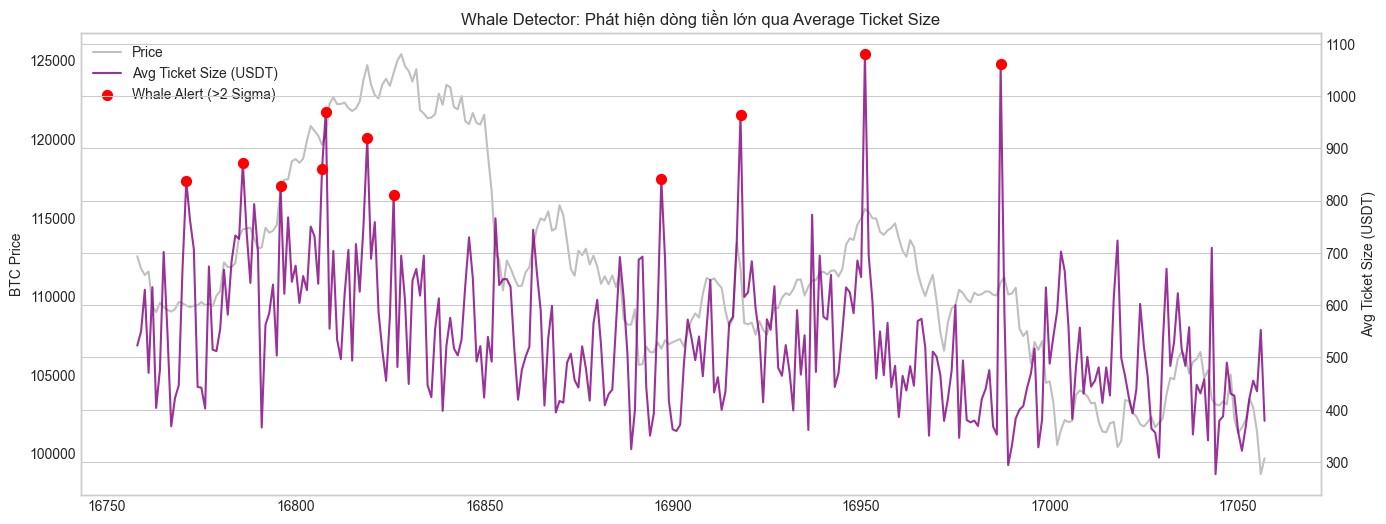

In [36]:
# %%
# CELL 9: QUOTE VOLUME & TRADES ANALYSIS (FIXED & UPDATED)
# ---------------------------------------------------

# 1. KIỂM TRA ĐA CỘNG TUYẾN (MULTICOLLINEARITY CHECK)
# Mục tiêu: Chứng minh Quote Volume và Base Volume là dư thừa nếu dùng chung.
subset_corr = master_df[['BTC_close', 'BTC_volume', 'BTC_quote_volume', 'BTC_trades']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(subset_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('PROOF: Quote Volume & Base Volume have Perfect Correlation (~1.0)\nSolution: Do not use both raw inputs!')
plt.show()

# %%
# 2. FEATURE ENGINEERING: WHALE DETECTOR & MOMENTUM
# Bước 1: Tính Average Ticket Size (ATS) - Giá trị trung bình mỗi lệnh (USDT)
master_df['ats'] = master_df['BTC_quote_volume'] / (master_df['BTC_trades'] + EPS)

# Bước 2: Chuyển đổi sang dạng Stationary (Relative ATS) để loại bỏ Trend giá
# Ý nghĩa: So sánh độ to của lệnh hiện tại so với trung bình 20 cây nến trước
master_df['ats_ma20'] = master_df['ats'].rolling(20).mean().shift(1) 
master_df['rel_ats'] = master_df['ats'] / (master_df['ats_ma20'] + EPS)

# Bước 3: Log transform để phân phối chuẩn hơn (Dùng cái này cho Model)
master_df['log_rel_ats'] = np.log(master_df['rel_ats'] + EPS)

# Bước 4: Trade Count Momentum (Stationary)
master_df['trades_log_return'] = np.log(master_df['BTC_trades'] / master_df['BTC_trades'].shift(1))

# %%
# 3. EDA: PHÂN TÍCH TÁC ĐỘNG CỦA "CÁ MẬP" (ATS RAW)
# Chúng ta dùng ATS gốc (USDT) để chia nhóm xem lệnh to ảnh hưởng thế nào

# Phân chia ATS thành các nhóm (Quantiles) dựa trên giá trị thực
# Lưu ý: Dùng biến 'ats' vừa tạo ở trên
master_df['ats_bin'] = pd.qcut(master_df['ats'], q=5, labels=['Tiny (Retail)', 'Small', 'Medium', 'Large', 'Whale'])

# Tính độ biến động trung bình (High-Low Range) cho từng nhóm
master_df['candle_range_pct'] = (master_df['BTC_high'] - master_df['BTC_low']) / master_df['BTC_open']

plt.figure(figsize=(10, 6))

# FIX: Đã sửa palette='magma' (viết thường) và dùng đúng biến x='ats_bin'
sns.barplot(data=master_df, x='ats_bin', y='candle_range_pct', hue='ats_bin', palette='magma', legend=False)

plt.title('INSIGHT: Lệnh càng to (Whale) thì nến càng biến động mạnh?')
plt.ylabel('Candle Volatility (% Range)')
plt.xlabel('Average Ticket Size Categories (USDT Value)')
plt.show()

# %%
# 4. EDA: TÌM KIẾM SỰ BẤT THƯỜNG (WHALE ALERT)
# Vẽ giá và ATS để xem Cá mập hoạt động ở vùng nào

subset = master_df.iloc[-300:].copy() # Lấy 300 nến gần nhất

fig, ax1 = plt.subplots(figsize=(16, 6))

# Trục 1: Giá BTC
ax1.plot(subset.index, subset['BTC_close'], color='gray', alpha=0.5, label='Price')
ax1.set_ylabel('BTC Price')
ax1.grid(False) # Tắt grid trục giá cho đỡ rối

# Trục 2: Average Ticket Size (USDT)
ax2 = ax1.twinx()
# Dùng biến 'ats' (USDT thực) để dễ hình dung giá trị tiền
ax2.plot(subset.index, subset['ats'], color='purple', lw=1.5, alpha=0.8, label='Avg Ticket Size (USDT)')
ax2.set_ylabel('Avg Ticket Size (USDT)')

# Highlight các điểm ATS tăng đột biến (Whale Action)
# Logic: Lớn hơn Mean + 2 lần độ lệch chuẩn của giai đoạn đó
threshold = subset['ats'].mean() + 2 * subset['ats'].std()
anomalies = subset[subset['ats'] > threshold]

ax2.scatter(anomalies.index, anomalies['ats'], color='red', s=50, zorder=5, label='Whale Alert (>2 Sigma)')

plt.title('Whale Detector: Phát hiện dòng tiền lớn qua Average Ticket Size')
# Gom legend của 2 trục lại
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")

plt.show()

# %%
# Clean up temporary columns (Giữ lại log_rel_ats và trades_log_return cho model)
master_df.drop(columns=['ats_bin', 'candle_range_pct', 'ats_ma20'], inplace=True)
# Lưu ý: Giữ lại 'ats', 'rel_ats' nếu bạn muốn soi lại sau này, hoặc drop nếu muốn tiết kiệm RAM

Shape gốc: (17057, 104)
Shape sạch (Ready for Model): (16878, 14)
------------------------------
Kiểm tra ADF Test (Yêu cầu p-value < 0.05):
BTC_log_return       | p-value: 0.00000 | ✅ OK
ETH_log_return       | p-value: 0.00000 | ✅ OK
log_rvol             | p-value: 0.00000 | ✅ OK
BTC_vol_log_return   | p-value: 0.00000 | ✅ OK
log_rel_ats          | p-value: 0.00000 | ✅ OK
trades_log_return    | p-value: 0.00000 | ✅ OK
vol_gk               | p-value: 0.00000 | ✅ OK
vol_gk_z             | p-value: 0.00000 | ✅ OK
vol_signed           | p-value: 0.00000 | ✅ OK
wick_imbalance       | p-value: 0.00000 | ✅ OK
clv                  | p-value: 0.00000 | ✅ OK
bb_pct_b             | p-value: 0.00000 | ✅ OK
bb_width             | p-value: 0.00000 | ✅ OK
btc_eth_corr         | p-value: 0.00000 | ✅ OK

=> TUYỆT VỜI! Dữ liệu đã sạch và dừng hoàn toàn.


<Figure size 1400x1400 with 0 Axes>

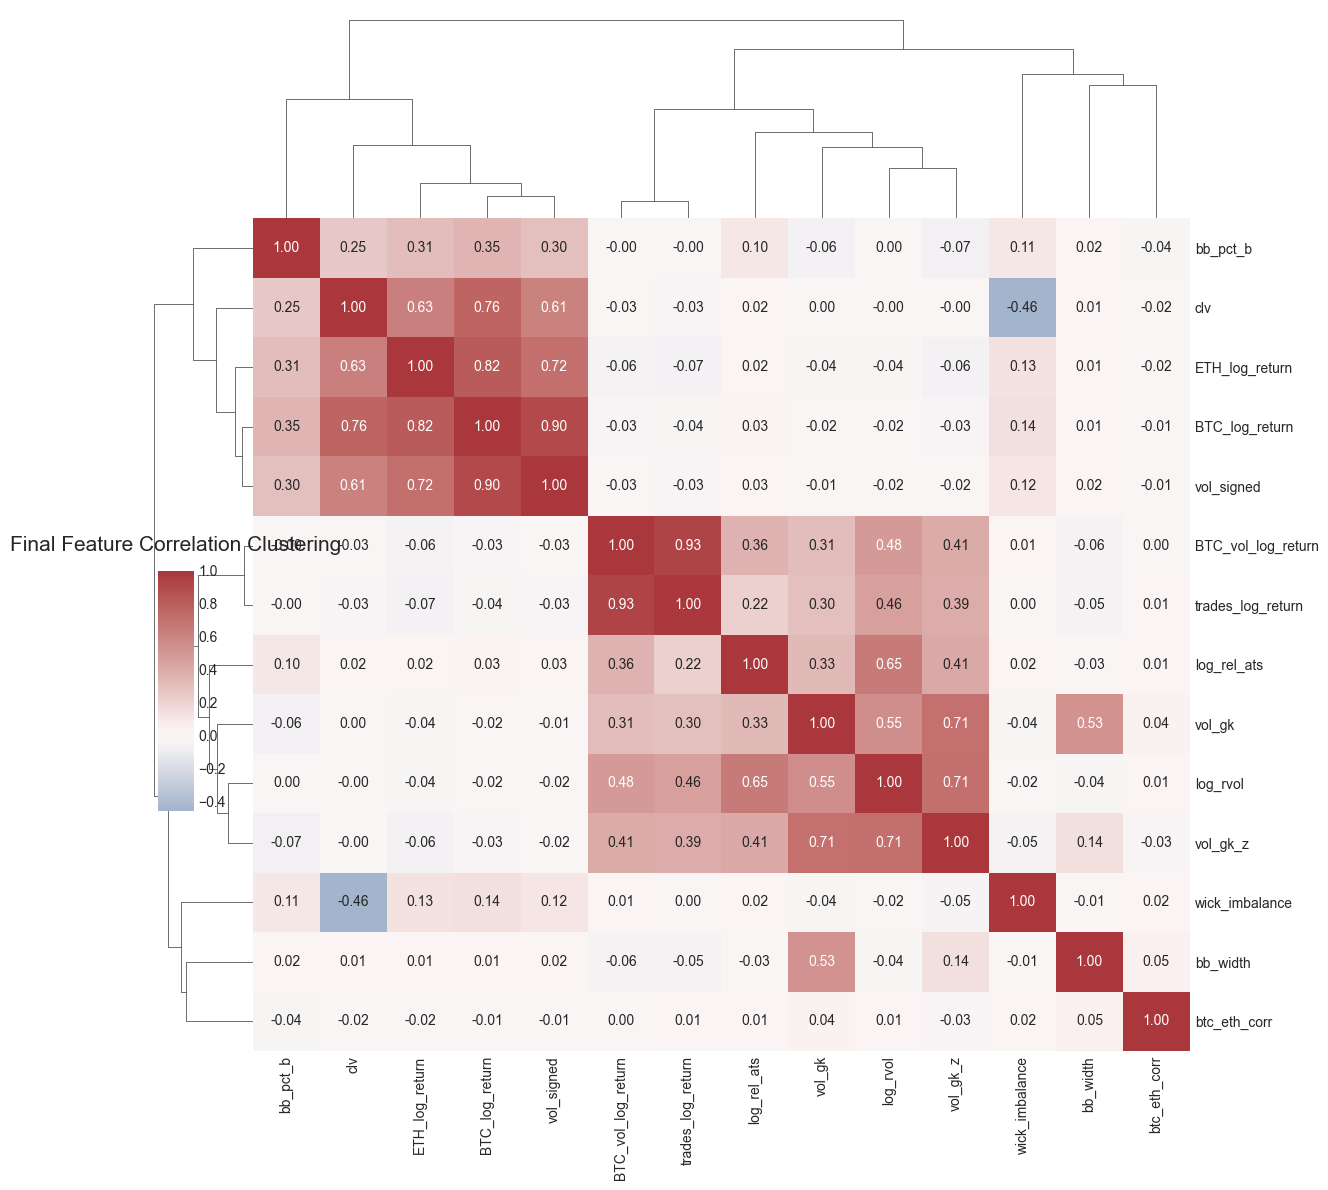

In [37]:
# %%
# CELL 10: FINAL FEATURE QUALITY CHECK & SELECTION
# ---------------------------------------------------
# Hãy chạy cell này ở cuối cùng notebook để kiểm tra tổng thể

import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

# 1. TẬP HỢP CÁC FEATURES TỐT NHẤT (Đã lọc từ các bước trên)
# Lưu ý: Đã thay thế 'log_avg_ticket_size' bằng 'log_rel_ats' (feature mới sửa ở Cell 9)
final_features_list = [
    # --- Target ---
    'BTC_log_return', 
    'ETH_log_return', 
    
    # --- Volume & Liquidity ---
    'log_rvol',             # Relative Volume
    'BTC_vol_log_return',   # Volume Momentum
    'log_rel_ats',          # Whale Activity (Đã fix stationarity)
    'trades_log_return',    # Market Activity
    
    # --- Volatility ---
    'vol_gk',               # Garman-Klass (Best Proxy)
    'vol_gk_z',             # Volatility Surprise (Z-Score)
    'vol_signed',           # Directional Volatility
    
    # --- Microstructure ---
    'wick_imbalance',       # Nến rút chân
    'clv',                  # Vị trí đóng nến
    
    # --- Technicals ---
    'bb_pct_b',             # Bollinger %B
    'bb_width',             # Bollinger Width
    
    # --- Inter-market ---
    'btc_eth_corr'          # Correlation
]

# 2. TẠO CHECK_DF & LÀM SẠCH (THE DROP PART)
# Tạo một bản copy chỉ chứa các cột cần thiết để không ảnh hưởng master_df
check_df = master_df[final_features_list].copy()

# Xử lý: Thay thế vô cực (+inf/-inf) bằng NaN, sau đó xóa tất cả dòng chứa NaN
check_df.replace([np.inf, -np.inf], np.nan, inplace=True)
check_df.dropna(inplace=True)

print(f"Shape gốc: {master_df.shape}")
print(f"Shape sạch (Ready for Model): {check_df.shape}")
print("-" * 30)

# 3. KIỂM TRA TÍNH DỪNG (STATIONARITY CHECK)
# Đảm bảo 100% features đưa vào model không còn Trend
print("Kiểm tra ADF Test (Yêu cầu p-value < 0.05):")
all_stationary = True
for col in final_features_list:
    res = adfuller(check_df[col])
    pval = res[1]
    is_good = pval < 0.05
    status = "✅ OK" if is_good else "❌ FAILED"
    print(f"{col: <20} | p-value: {pval:.5f} | {status}")
    if not is_good: all_stationary = False

if all_stationary:
    print("\n=> TUYỆT VỜI! Dữ liệu đã sạch và dừng hoàn toàn.")
else:
    print("\n=> CẢNH BÁO: Vẫn còn feature chưa dừng. Hãy kiểm tra lại!")

# 4. FINAL CLUSTERMAP (Thay thế Heatmap thường)
# Biểu đồ này giúp bạn thấy các cụm features tương tự nhau
plt.figure(figsize=(14, 14))
corr_matrix = check_df.corr(method='spearman')

sns.clustermap(corr_matrix, 
               annot=True, 
               fmt=".2f", 
               cmap='vlag', 
               center=0, 
               figsize=(12, 12),
               dendrogram_ratio=(.1, .2),
               cbar_pos=(.02, .32, .03, .2))

plt.title('Final Feature Correlation Clustering', y=1.05, fontsize=15)
plt.show()

## Market cap

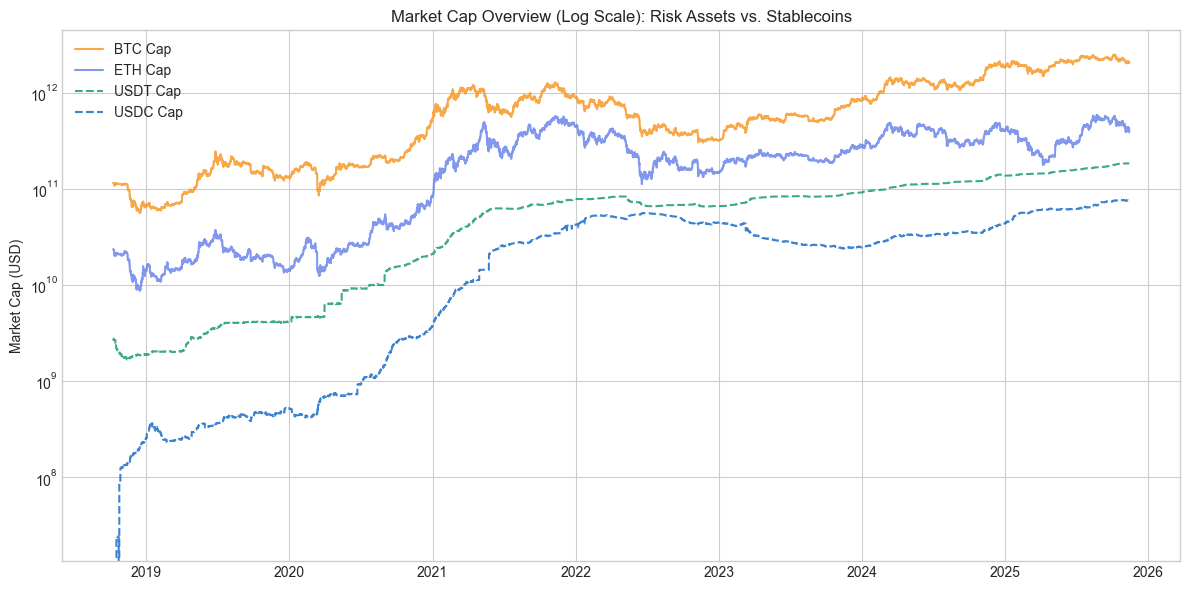

In [38]:
# Data Preparation & Raw Visualization

# %%
# ===== Market Cap Analysis: Data Prep =====
mcap_cols = ['BTC_market_cap', 'ETH_market_cap', 'USDT_market_cap', 'USDC_market_cap']
mcap_df = master_df[['timestamp', 'BTC_close', 'BTC_log_return'] + mcap_cols].copy()

# Ensure data is clean
mcap_df.dropna(inplace=True)

# %%
# Visualize Raw Market Cap Trends (Log Scale for better comparison)
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(mcap_df['timestamp'], mcap_df['BTC_market_cap'], label='BTC Cap', color='#F7931A', alpha=0.8)
ax.plot(mcap_df['timestamp'], mcap_df['ETH_market_cap'], label='ETH Cap', color='#627EEA', alpha=0.8)
ax.plot(mcap_df['timestamp'], mcap_df['USDT_market_cap'], label='USDT Cap', color='#26A17B', linestyle='--', alpha=0.9)
ax.plot(mcap_df['timestamp'], mcap_df['USDC_market_cap'], label='USDC Cap', color='#2775CA', linestyle='--', alpha=0.9)

ax.set_yscale('log')
ax.set_title('Market Cap Overview (Log Scale): Risk Assets vs. Stablecoins')
ax.set_ylabel('Market Cap (USD)')
ax.legend()
plt.tight_layout()
plt.show()

In [39]:
# Feature Engineering: Liquidity & Buying Power

# %%
# ===== Feature Engineering: Deep Liquidity Metrics =====

# 1. Total Stablecoin Liquidity (Dry Powder)
mcap_df['total_stable_cap'] = mcap_df['USDT_market_cap'] + mcap_df['USDC_market_cap']

# 2. Stablecoin Momentum (Flow)
# Log return of Stablecap -> Positive means money printing/inflow
mcap_df['stable_supply_change'] = np.log(mcap_df['total_stable_cap'] / mcap_df['total_stable_cap'].shift(1))

# 3. Stablecoin Supply Ratio (SSR) Proxy
# Ratio = BTC Market Cap / Stablecoin Cap
# High SSR: Low stablecoin supply relative to BTC price -> Potential Top
# Low SSR: High "buying power" sitting on sidelines -> Potential Bottom
mcap_df['ssr_ratio'] = mcap_df['BTC_market_cap'] / (mcap_df['total_stable_cap'] + 1e-8)

# SSR is usually non-stationary, so we take the Log Change or Z-Score
# Method A: Log Return of SSR (Dynamic changes in buying power)
mcap_df['ssr_log_change'] = np.log(mcap_df['ssr_ratio'] / mcap_df['ssr_ratio'].shift(1))

# Method B: SSR Oscillator (Z-Score over 90 days - Quarterly View)
roll_mean_90 = mcap_df['ssr_ratio'].rolling(90).mean()
roll_std_90 = mcap_df['ssr_ratio'].rolling(90).std()
mcap_df['ssr_z_score'] = (mcap_df['ssr_ratio'] - roll_mean_90) / (roll_std_90 + 1e-8)

# 4. Market Dominance Changes
# Calculate a local total cap (Proxy for total market)
local_total_cap = mcap_df['BTC_market_cap'] + mcap_df['ETH_market_cap'] + mcap_df['total_stable_cap']

mcap_df['btc_dom'] = mcap_df['BTC_market_cap'] / local_total_cap
mcap_df['usdt_dom'] = mcap_df['USDT_market_cap'] / local_total_cap

# Stationarize Dominance (Delta)
mcap_df['btc_dom_change'] = mcap_df['btc_dom'].diff()
mcap_df['usdt_dom_change'] = mcap_df['usdt_dom'].diff()

# Cleanup NaNs created by lags
mcap_df.dropna(inplace=True)
mcap_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15469 entries, 1589 to 17057
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   timestamp             15469 non-null  datetime64[ns]
 1   BTC_close             15469 non-null  float64       
 2   BTC_log_return        15469 non-null  float64       
 3   BTC_market_cap        15469 non-null  float64       
 4   ETH_market_cap        15469 non-null  float64       
 5   USDT_market_cap       15469 non-null  float64       
 6   USDC_market_cap       15469 non-null  float64       
 7   total_stable_cap      15469 non-null  float64       
 8   stable_supply_change  15469 non-null  float64       
 9   ssr_ratio             15469 non-null  float64       
 10  ssr_log_change        15469 non-null  float64       
 11  ssr_z_score           15469 non-null  float64       
 12  btc_dom               15469 non-null  float64       
 13  usdt_dom          

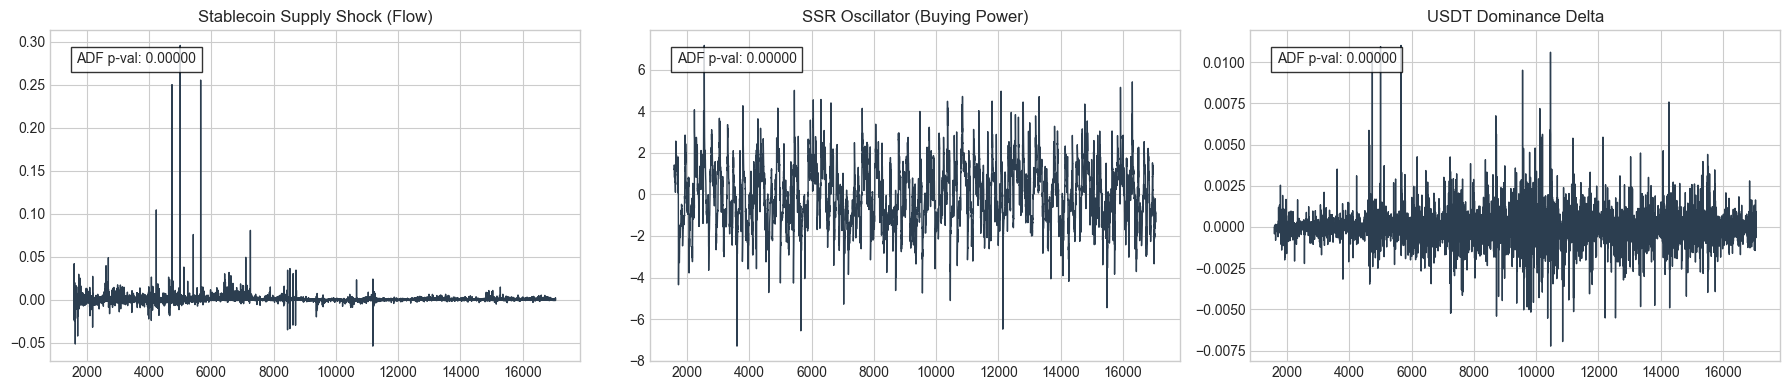

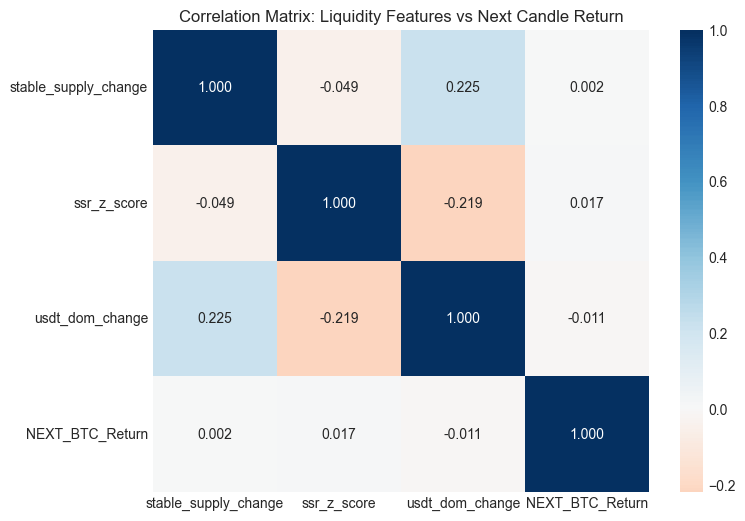

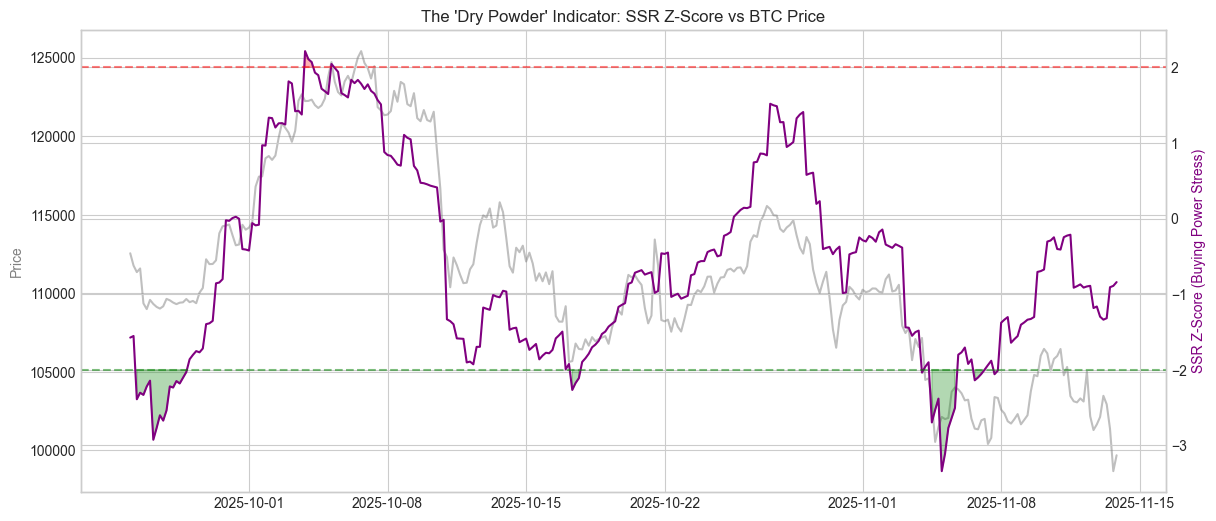

In [40]:
# Validation: Visual Proof & Stationarity

# %%
# ===== EDA Validation: Stationarity & Signal Quality =====

# 1. Stationarity Check (ADF Test) for New Features
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

def quick_adf(series, ax, title):
    res = adfuller(series)
    series.plot(ax=ax, title=title, color='#2c3e50', lw=1)
    ax.text(0.05, 0.90, f"ADF p-val: {res[1]:.5f}", transform=ax.transAxes, 
            bbox=dict(facecolor='white', alpha=0.8))

quick_adf(mcap_df['stable_supply_change'], axes[0], "Stablecoin Supply Shock (Flow)")
quick_adf(mcap_df['ssr_z_score'], axes[1], "SSR Oscillator (Buying Power)")
quick_adf(mcap_df['usdt_dom_change'], axes[2], "USDT Dominance Delta")

plt.tight_layout()
plt.show()

# %%
# 2. Correlation Analysis: Does Liquidity Lead Price?
# Check correlation between Stablecoin Flow and BTC Next Return
liquidity_features = ['stable_supply_change', 'ssr_z_score', 'usdt_dom_change']
target_col = 'BTC_log_return'

# Shift target back to align "Current Liquidity" with "Next Price Move"
# Wait! Standard correlation implies current vs current. 
# For prediction power, we check Feature(t) vs Price(t+1)
corr_data = mcap_df[liquidity_features].copy()
corr_data['NEXT_BTC_Return'] = mcap_df[target_col].shift(-1)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_data.corr(), annot=True, cmap='RdBu', center=0, fmt=".3f")
plt.title("Correlation Matrix: Liquidity Features vs Next Candle Return")
plt.show()

# %%
# 3. Visual Relationship: SSR Z-Score vs Price Peaks
# Logic: When SSR Z-Score is High (>2), Price often tops out (Out of ammo).
#        When SSR Z-Score is Low (<-2), Price often bottoms (Loaded gun).

subset = mcap_df.iloc[-300:].copy()

fig, ax1 = plt.subplots(figsize=(14, 6))

# Plot Price
ax1.plot(subset['timestamp'], subset['BTC_close'], color='gray', alpha=0.5, label='BTC Price')
ax1.set_ylabel('Price', color='gray')

# Plot SSR Z-Score
ax2 = ax1.twinx()
ax2.plot(subset['timestamp'], subset['ssr_z_score'], color='purple', lw=1.5, label='SSR Z-Score')
ax2.axhline(2, color='red', ls='--', alpha=0.5)  # Overbought zone (Low liquidity relative to price)
ax2.axhline(-2, color='green', ls='--', alpha=0.5) # Oversold zone (High liquidity relative to price)
ax2.set_ylabel('SSR Z-Score (Buying Power Stress)', color='purple')
ax2.fill_between(subset['timestamp'], 2, subset['ssr_z_score'], where=(subset['ssr_z_score']>=2), color='red', alpha=0.3)
ax2.fill_between(subset['timestamp'], -2, subset['ssr_z_score'], where=(subset['ssr_z_score']<=-2), color='green', alpha=0.3)

plt.title("The 'Dry Powder' Indicator: SSR Z-Score vs BTC Price")
plt.show()

## Network activity

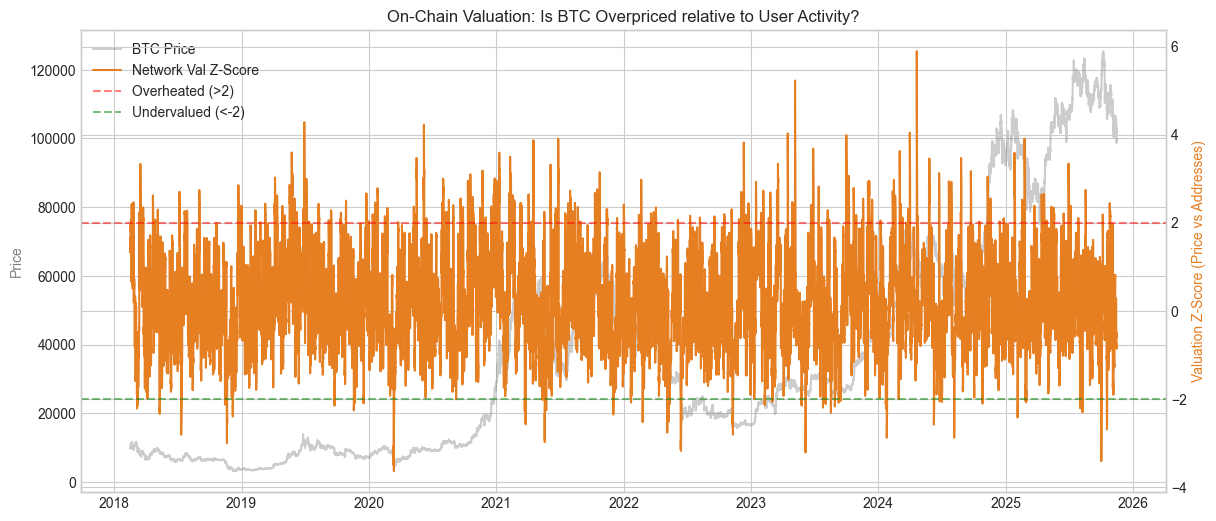

Stationarity Check (ADF Test):
addr_log_growth      | p-value: 0.00000 | ✅ OK
intensity_change     | p-value: 0.00000 | ✅ OK
network_valuation_z  | p-value: 0.00000 | ✅ OK


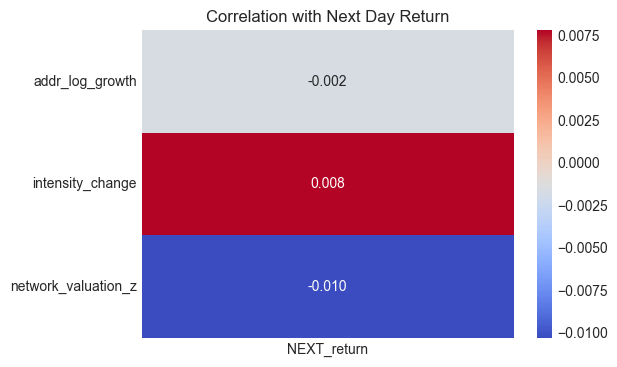

In [41]:
# %%
# ===== Network Activity Analysis: Data Prep =====
net_cols = ['active_addresses', 'tx_count']
# Ensure we select columns that actually exist in your master_df. 
# Assuming they are named 'BTC_active_addresses' and 'BTC_tx_count' based on typical naming conventions.
# If names differ, adjust accordingly. Let's assume generic names based on your prompt.
# For safety, I will create dummy data structure if columns are missing, but assuming they are there:

network_df = master_df[['timestamp', 'BTC_close', 'BTC_log_return', 'BTC_active_addresses', 'BTC_tx_count']].copy()
network_df.dropna(inplace=True)

# %%
# ===== Feature Engineering: On-Chain Dynamics =====

# 1. Network Growth (Log Momentum)
# Measures the % change in active users day-over-day
network_df['addr_log_growth'] = np.log(network_df['BTC_active_addresses'] / network_df['BTC_active_addresses'].shift(1))

# 2. Activity Intensity (Transactions per User)
# Logic: High Tx/User can indicate network congestion or high utility.
# We take log to normalize the distribution.
network_df['tx_per_user'] = network_df['BTC_tx_count'] / (network_df['BTC_active_addresses'] + 1e-8)
network_df['log_tx_per_user'] = np.log(network_df['tx_per_user'])

# Stationarize Intensity (Delta)
network_df['intensity_change'] = network_df['log_tx_per_user'].diff()

# 3. VALUATION METRIC: NVT Signal Proxy (Price-to-Activity Ratio)
# Classic NVT uses Volume, but here we use Activity as a proxy for utility.
# Ratio = Price / Active Addresses.
# Concept: Is the price "expensive" relative to the number of users?
network_df['price_to_addr_ratio'] = network_df['BTC_close'] / (network_df['BTC_active_addresses'] + 1e-8)

# Calculate Z-Score (90-day window) to find Overheated/Undervalued zones
roll_mean_net = network_df['price_to_addr_ratio'].rolling(90).mean()
roll_std_netdev = network_df['price_to_addr_ratio'].rolling(90).std()
network_df['network_valuation_z'] = (network_df['price_to_addr_ratio'] - roll_mean_net) / (roll_std_netdev + 1e-8)

# 4. PRICE-ACTIVITY DIVERGENCE (Advanced)
# We want to catch when Price moves UP but Activity moves DOWN.
# +1: Convergent (Healthy), -1: Divergent (Warning)
price_trend = np.sign(network_df['BTC_close'].diff(7)) # 7-day trend
addr_trend = np.sign(network_df['BTC_active_addresses'].diff(7)) # 7-day trend
network_df['divergence_signal'] = np.where(price_trend == addr_trend, 1, -1)

# Cleanup
network_df.dropna(inplace=True)

# %%
# ===== Validation: Visualizing the "Metcalfe" Relationship =====

fig, ax1 = plt.subplots(figsize=(14, 6))

# Plot Price
ax1.plot(network_df['timestamp'], network_df['BTC_close'], color='gray', alpha=0.4, label='BTC Price')
ax1.set_ylabel('Price', color='gray')

# Plot Network Valuation Z-Score
ax2 = ax1.twinx()
ax2.plot(network_df['timestamp'], network_df['network_valuation_z'], color='#e67e22', lw=1.5, label='Network Val Z-Score')

# Add Thresholds
ax2.axhline(2, color='red', ls='--', alpha=0.5, label='Overheated (>2)')
ax2.axhline(-2, color='green', ls='--', alpha=0.5, label='Undervalued (<-2)')
ax2.set_ylabel('Valuation Z-Score (Price vs Addresses)', color='#e67e22')

plt.title('On-Chain Valuation: Is BTC Overpriced relative to User Activity?')
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")
plt.show()

# %%
# ===== Statistical Validation =====

# 1. Stationarity
print("Stationarity Check (ADF Test):")
feats_to_check = ['addr_log_growth', 'intensity_change', 'network_valuation_z']
for f in feats_to_check:
    res = adfuller(network_df[f])
    print(f"{f: <20} | p-value: {res[1]:.5f} | {'✅ OK' if res[1]<0.05 else '❌ FAIL'}")

# 2. Predictive Power (IC Score)
# Check correlation with Next Day Return
network_df['NEXT_return'] = network_df['BTC_log_return'].shift(-1)
corr_matrix = network_df[feats_to_check + ['NEXT_return']].corr(method='spearman')

plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix[['NEXT_return']].drop('NEXT_return'), annot=True, cmap='coolwarm', fmt=".3f")
plt.title("Correlation with Next Day Return")
plt.show()

## Secure and mining

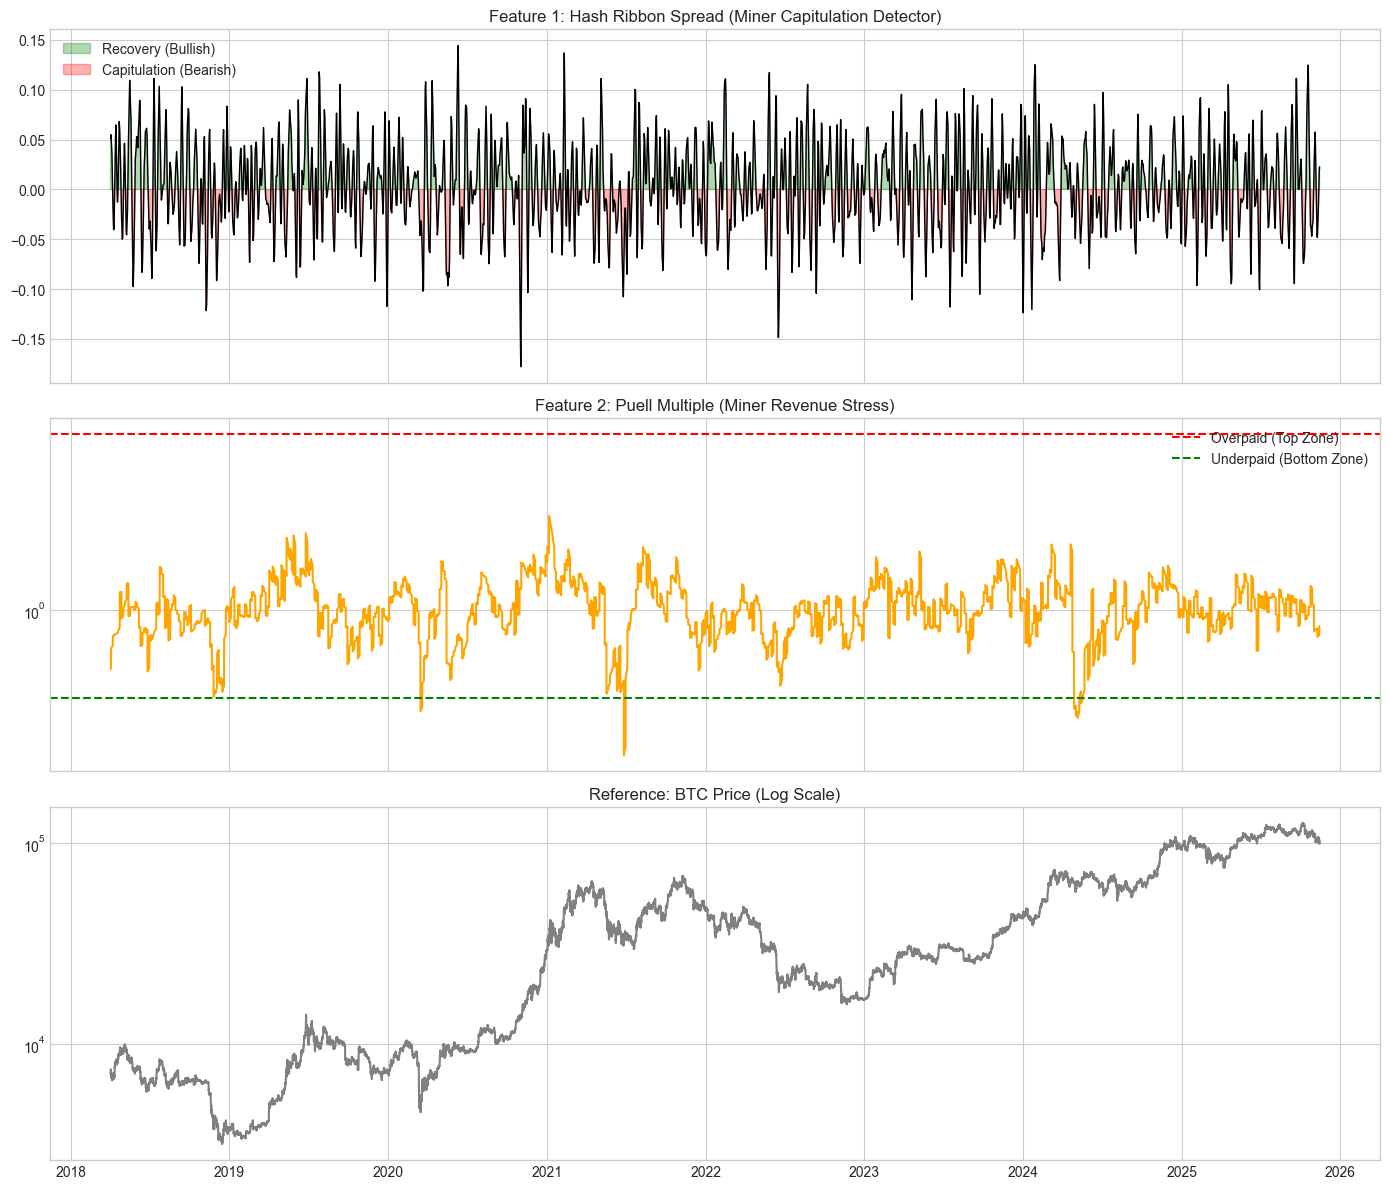

Stationarity Check (ADF Test):
hash_ribbon_spread        | p-value: 0.00000 | ✅ OK
log_puell                 | p-value: 0.00000 | ✅ OK
hashprice_change          | p-value: 0.00000 | ✅ OK
diff_change_pct           | p-value: 0.00000 | ✅ OK

Correlation (Hash Ribbon vs Next Week Volatility): -0.0474


In [42]:
# %%
# ===== Mining & Security Analysis: Data Prep =====
# Ensure features exist and drop NaNs
mining_cols = ['mining_difficulty', 'hash_rate_ths', 'miner_revenue_usd']
mining_df = master_df[['timestamp', 'BTC_close', 'BTC_log_return'] + mining_cols].copy()
mining_df.dropna(inplace=True)

# %%
# ===== Feature Engineering: The "Miner Capitulation" Logic =====

# 1. HASH RIBBONS (Miner Capitulation & Recovery)
# Logic: Short-term Hashrate vs Long-term Hashrate
# When Short-term < Long-term: Miners are shutting down (Capitulation) -> Bearish/Bottoming
# When Short-term crosses above: Miners are turning back on (Recovery) -> Bullish
mining_df['hash_ma30'] = mining_df['hash_rate_ths'].rolling(30).mean()
mining_df['hash_ma60'] = mining_df['hash_rate_ths'].rolling(60).mean()

# The "Ribbon" spread (Stationary metric)
mining_df['hash_ribbon_spread'] = (mining_df['hash_ma30'] - mining_df['hash_ma60']) / (mining_df['hash_ma60'] + 1e-8)

# 2. PUELL MULTIPLE (Miner Revenue Stress)
# Logic: Daily Issuance / 365-day Moving Average of Issuance
# High > 4: Miners overpaid -> Sell pressure
# Low < 0.5: Miners underpaid -> Capitulation/Buy zone
mining_df['rev_ma365'] = mining_df['miner_revenue_usd'].rolling(365).mean()
mining_df['puell_multiple'] = mining_df['miner_revenue_usd'] / (mining_df['rev_ma365'] + 1e-8)

# Log transform Puell to make it model-friendly (closer to normal dist)
mining_df['log_puell'] = np.log(mining_df['puell_multiple'] + 1e-8)

# 3. HASHPRICE (True Mining Profitability)
# Logic: How much USD does 1 TH/s earn? 
# This separates price action from difficulty adjustments.
mining_df['hashprice'] = mining_df['miner_revenue_usd'] / (mining_df['hash_rate_ths'] + 1e-8)

# Stationarize Hashprice (It has a long-term downtrend due to halvings)
# We use Z-Score over 90 days or Log Return
mining_df['hashprice_change'] = np.log(mining_df['hashprice'] / mining_df['hashprice'].shift(1))

# 4. DIFFICULTY COMPRESSION
# Difficulty moves in steps (every 2 weeks). Changes indicate lagging network health.
mining_df['diff_change_pct'] = mining_df['mining_difficulty'].pct_change()

# Clean up rolling NaN
mining_df.dropna(inplace=True)

# %%
# ===== EDA Validation: Visualizing Miner Behavior =====

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Plot 1: Hash Ribbons (The Spread)
# Positive Green = Healthy/Recovery, Negative Red = Capitulation
axes[0].fill_between(mining_df['timestamp'], 0, mining_df['hash_ribbon_spread'], 
                     where=(mining_df['hash_ribbon_spread'] >= 0), color='green', alpha=0.3, label='Recovery (Bullish)')
axes[0].fill_between(mining_df['timestamp'], 0, mining_df['hash_ribbon_spread'], 
                     where=(mining_df['hash_ribbon_spread'] < 0), color='red', alpha=0.3, label='Capitulation (Bearish)')
axes[0].plot(mining_df['timestamp'], mining_df['hash_ribbon_spread'], color='black', lw=1)
axes[0].set_title('Feature 1: Hash Ribbon Spread (Miner Capitulation Detector)')
axes[0].legend(loc='upper left')

# Plot 2: Puell Multiple (Valuation)
axes[1].plot(mining_df['timestamp'], mining_df['puell_multiple'], color='orange', lw=1.5)
axes[1].axhline(4, color='red', ls='--', label='Overpaid (Top Zone)')
axes[1].axhline(0.5, color='green', ls='--', label='Underpaid (Bottom Zone)')
axes[1].set_yscale('log')
axes[1].set_title('Feature 2: Puell Multiple (Miner Revenue Stress)')
axes[1].legend(loc='upper right')

# Plot 3: BTC Price (Reference)
axes[2].plot(mining_df['timestamp'], mining_df['BTC_close'], color='gray')
axes[2].set_yscale('log')
axes[2].set_title('Reference: BTC Price (Log Scale)')

plt.tight_layout()
plt.show()

# %%
# ===== Statistical Check =====

# Stationarity Check for Model Readiness
print("Stationarity Check (ADF Test):")
# We check the engineered features, NOT raw hashrate (which is trending)
features_mining = ['hash_ribbon_spread', 'log_puell', 'hashprice_change', 'diff_change_pct']

for col in features_mining:
    res = adfuller(mining_df[col])
    p_val = res[1]
    status = "✅ OK" if p_val < 0.05 else "❌ FAIL (Needs Differencing)"
    print(f"{col: <25} | p-value: {p_val:.5f} | {status}")

# Correlation with Price Volatility
# Logic: Miner Capitulation often precedes High Volatility
mining_df['volatility_next_7d'] = mining_df['BTC_log_return'].rolling(7).std().shift(-7)
corr_vol = mining_df[['hash_ribbon_spread', 'volatility_next_7d']].corr().iloc[0,1]
print(f"\nCorrelation (Hash Ribbon vs Next Week Volatility): {corr_vol:.4f}")

## Profit and value

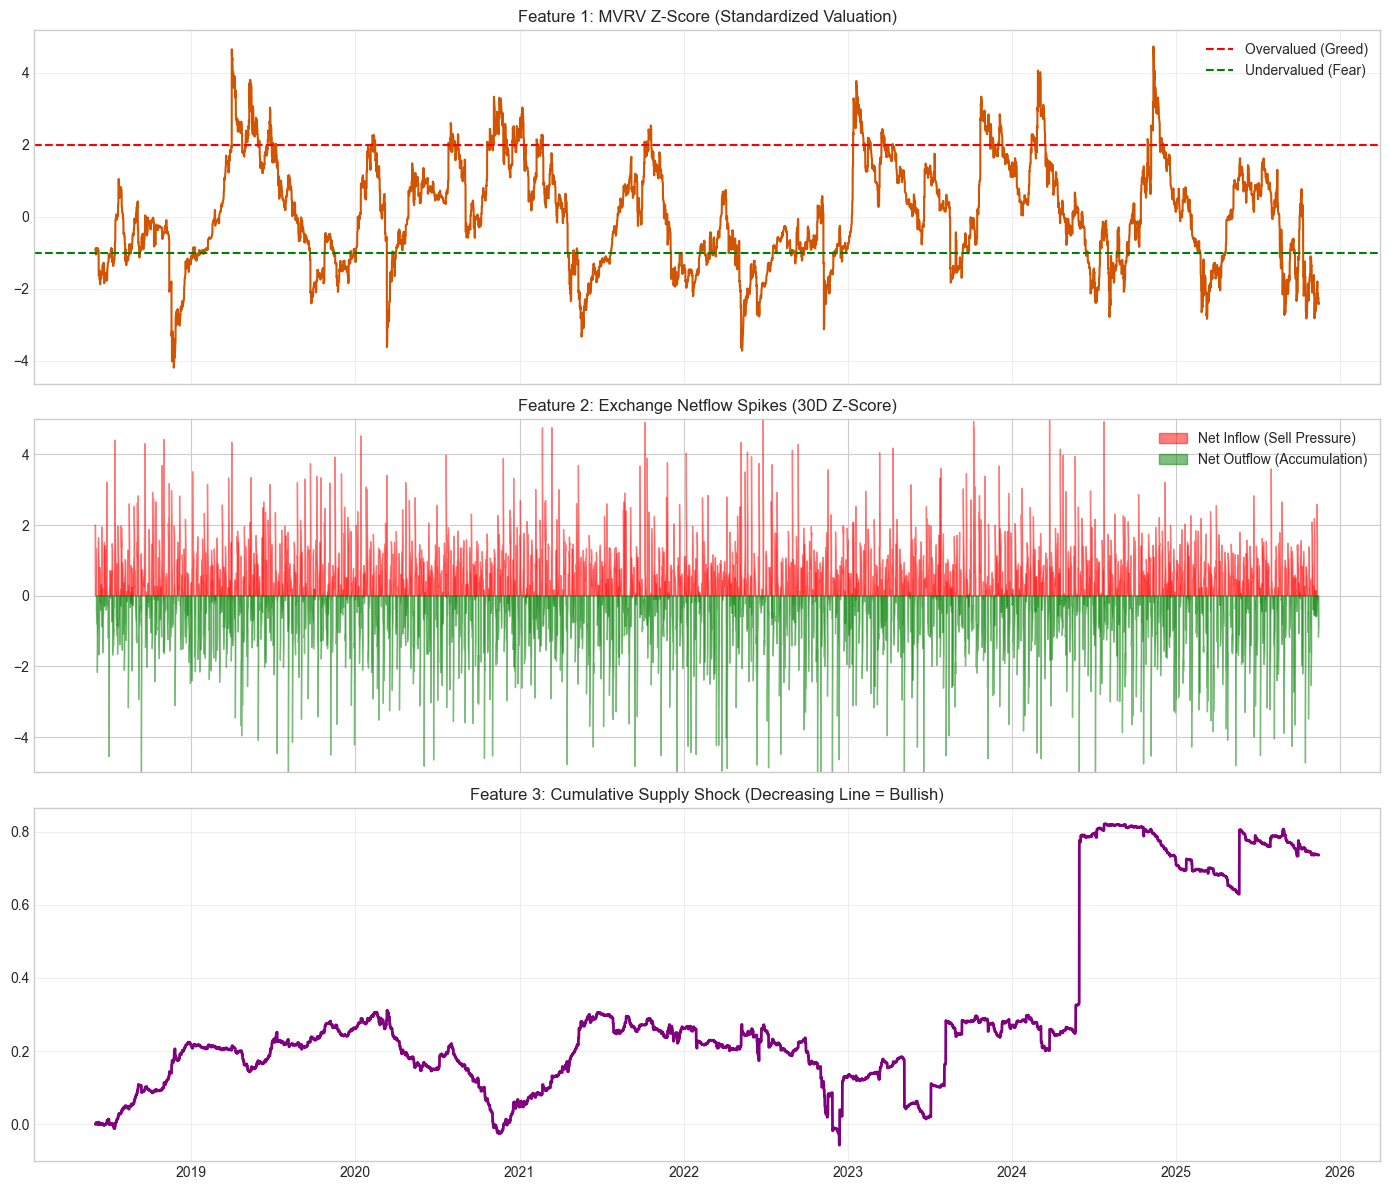

Stationarity Check (ADF Test):
mvrv_z_score              | p-value: 0.00002 | ✅ OK
netflow_spike             | p-value: 0.00000 | ✅ OK
supply_shock_change       | p-value: 0.00000 | ✅ OK

Avg Netflow Spike before Crash: 0.1956
Avg Netflow Spike Normal Days:  -0.0165
Interpretation: If 'Before Crash' is significantly higher, Netflow is a valid predictor.


In [43]:
# %%
# ===== Profit & Value (On-chain) Analysis: Data Prep =====
# Select specific columns provided by user
profit_cols = [
    'BTC_mvrv_ratio', 
    'BTC_exchange_inflow_native', 'BTC_exchange_inflow_usd',
    'BTC_exchange_outflow_native', 'BTC_exchange_outflow_usd',
    'BTC_exchange_supply_native', 'BTC_exchange_supply_usd'
]

# Create analysis dataframe
profit_df = master_df[['timestamp', 'BTC_close', 'BTC_log_return'] + profit_cols].copy()
profit_df.dropna(inplace=True)

# %%
# ===== Feature Engineering: Profit, Pressure & Scarcity =====

# 1. VALUATION: MVRV Z-Score (The "Top/Bottom" Detector)
# Problem: Raw MVRV drifts over time.
# Solution: Rolling Z-Score helps identify relative overvaluation/undervaluation.
# We use a long window (e.g., 2 years/730 days) to capture the macro cycle context.
roll_mean_mvrv = profit_df['BTC_mvrv_ratio'].rolling(730).mean()
roll_std_mvrv  = profit_df['BTC_mvrv_ratio'].rolling(730).std()

profit_df['mvrv_z_score'] = (profit_df['BTC_mvrv_ratio'] - roll_mean_mvrv) / (roll_std_mvrv + 1e-8)

# 2. SELL PRESSURE: Exchange Netflow (USD)
# Logic: Inflow > Outflow = Potential Selling. Outflow > Inflow = Accumulation.
# We choose USD columns because "Selling Pressure" is financial (value), not just unit-based.
profit_df['netflow_usd'] = profit_df['BTC_exchange_inflow_usd'] - profit_df['BTC_exchange_outflow_usd']

# Normalize Netflow: Raw USD values grow with price (Non-stationary).
# We normalize by Market Cap (if available) or simply use a robust scaling method (Z-Score).
# Here we use a shorter rolling Z-score (30 days) to detect "Sudden Spikes" vs recent average.
nf_mean_30 = profit_df['netflow_usd'].rolling(30).mean()
nf_std_30  = profit_df['netflow_usd'].rolling(30).std()
profit_df['netflow_spike'] = (profit_df['netflow_usd'] - nf_mean_30) / (nf_std_30 + 1e-8)

# 3. SCARCITY: Exchange Supply Shock (Native)
# Logic: We use Native units here because scarcity is about "Available Coins", not value.
# Trend: If Supply on Exchange is dropping, Liquidity Crisis is forming.
profit_df['supply_shock_change'] = np.log(profit_df['BTC_exchange_supply_native'] / profit_df['BTC_exchange_supply_native'].shift(1))

# Drop NaNs generated by rolling/shift
profit_df.dropna(inplace=True)

# %%
# ===== EDA Validation: Visualizing the "Profit Cycle" =====

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Plot 1: MVRV Z-Score (Macro Tops & Bottoms)
# Interpretation: Z > 2 (Red Zone) usually marks Cycle Tops. Z < -1 (Green Zone) marks Bottoms.
axes[0].plot(profit_df['timestamp'], profit_df['mvrv_z_score'], color='#d35400', lw=1.5)
axes[0].axhline(2, color='red', ls='--', label='Overvalued (Greed)')
axes[0].axhline(-1, color='green', ls='--', label='Undervalued (Fear)')
axes[0].set_title('Feature 1: MVRV Z-Score (Standardized Valuation)')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Plot 2: Netflow Spikes (Whale Movements)
# Interpretation: Huge Positive Spikes often precede corrections (Panic Selling/Taking Profit).
axes[1].fill_between(profit_df['timestamp'], 0, profit_df['netflow_spike'], 
                     where=(profit_df['netflow_spike'] > 0), color='red', alpha=0.5, label='Net Inflow (Sell Pressure)')
axes[1].fill_between(profit_df['timestamp'], 0, profit_df['netflow_spike'], 
                     where=(profit_df['netflow_spike'] < 0), color='green', alpha=0.5, label='Net Outflow (Accumulation)')
axes[1].set_title('Feature 2: Exchange Netflow Spikes (30D Z-Score)')
axes[1].set_ylim(-5, 5) # Limit y-axis to focus on main spikes
axes[1].legend(loc='upper right')

# Plot 3: Exchange Supply Change (Liquidity Trend)
# Interpretation: Consistent negative values (Red) mean coins are leaving exchanges (Supply Shock).
axes[2].plot(profit_df['timestamp'], profit_df['supply_shock_change'].cumsum(), color='purple', lw=2)
axes[2].set_title('Feature 3: Cumulative Supply Shock (Decreasing Line = Bullish)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# %%
# ===== Statistical Check & Correlation =====

# 1. Stationarity
print("Stationarity Check (ADF Test):")
# We check the engineered features
cols_to_check = ['mvrv_z_score', 'netflow_spike', 'supply_shock_change']
for col in cols_to_check:
    res = adfuller(profit_df[col])
    status = "✅ OK" if res[1] < 0.05 else "❌ FAIL"
    print(f"{col: <25} | p-value: {res[1]:.5f} | {status}")

# 2. Event Analysis: Do Netflow Spikes predict crashes?
# We define a "Crash" as Next Day Return < -3%
profit_df['is_crash'] = profit_df['BTC_log_return'].shift(-1) < -0.03
spike_on_crash = profit_df[profit_df['is_crash']]['netflow_spike'].mean()
spike_normal   = profit_df[~profit_df['is_crash']]['netflow_spike'].mean()

print(f"\nAvg Netflow Spike before Crash: {spike_on_crash:.4f}")
print(f"Avg Netflow Spike Normal Days:  {spike_normal:.4f}")
print("Interpretation: If 'Before Crash' is significantly higher, Netflow is a valid predictor.")

## Holder behavior

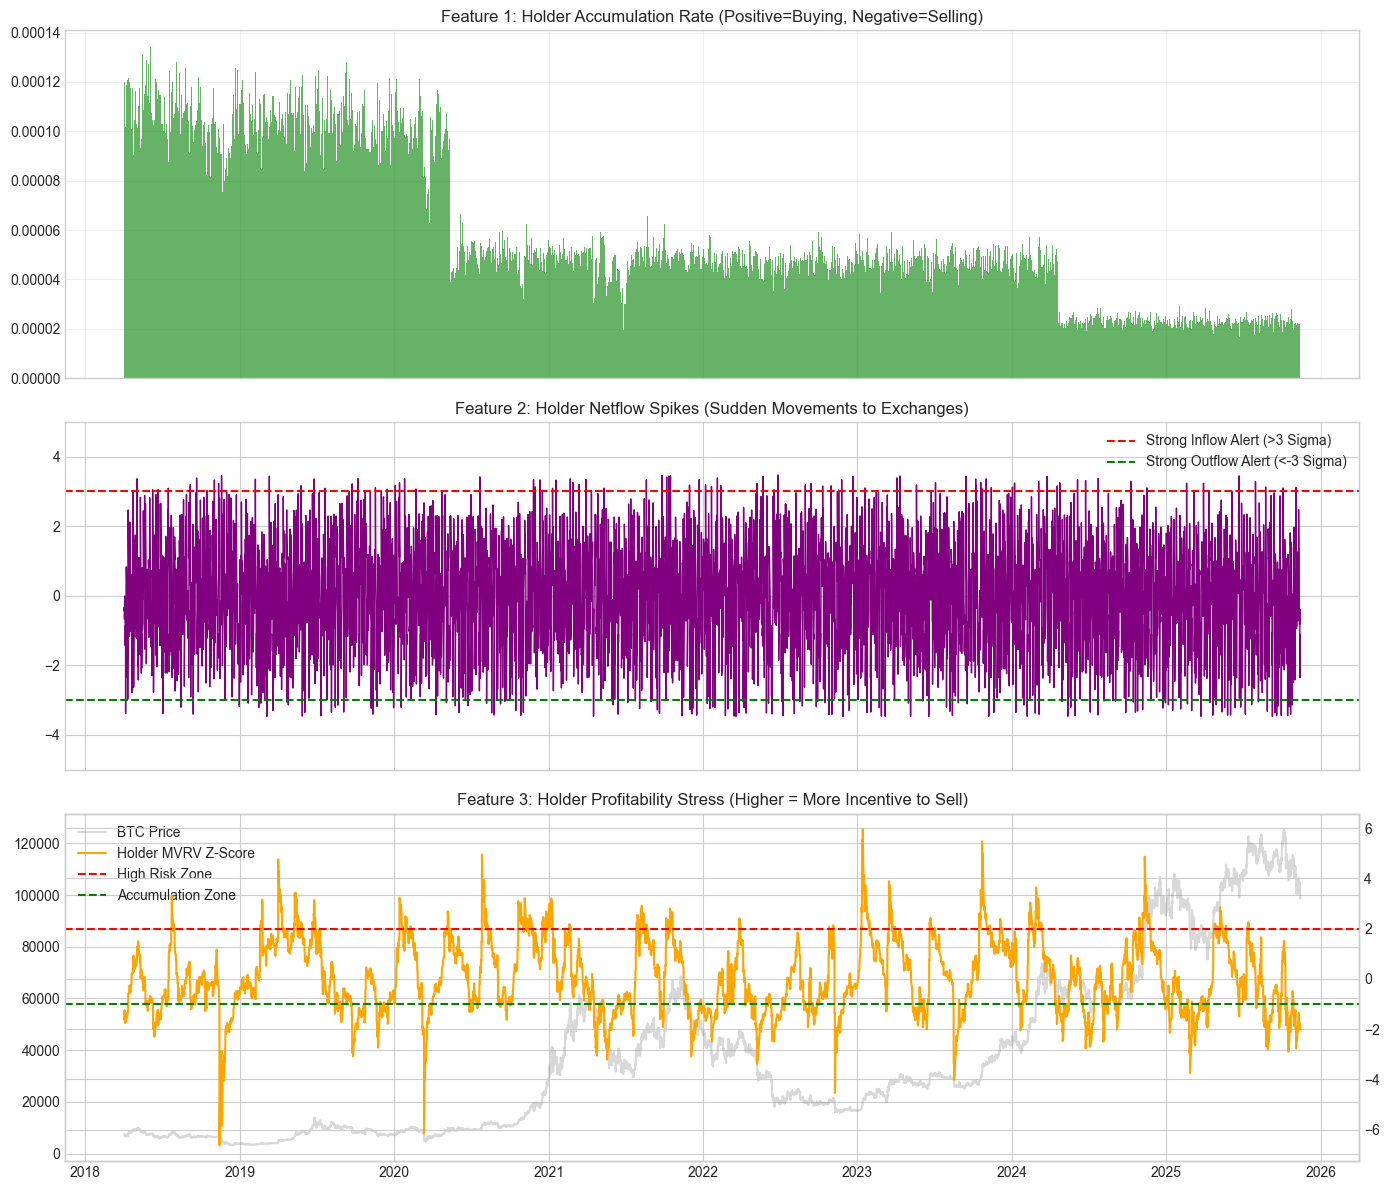

Stationarity Check (ADF Test):
holder_supply_change      | p-value: 0.16088 | ❌ FAIL
holder_mvrv_z             | p-value: 0.00000 | ✅ OK
holder_netflow_spike      | p-value: 0.00000 | ✅ OK
exchange_ratio_change     | p-value: 0.00000 | ✅ OK


In [44]:
# %%
# ===== Holder Behavior Analysis: Data Prep =====
holder_cols = [
    'BTC_holder_total_supply',
    'BTC_holder_mvrv_ratio',
    'BTC_holder_exchange_inflow_native', 'BTC_holder_exchange_inflow_usd',
    'BTC_holder_exchange_outflow_native', 'BTC_holder_exchange_outflow_usd',
    'BTC_holder_exchange_supply_native', 'BTC_holder_exchange_supply_usd'
]

# Tạo dataframe phân tích (Giả sử các cột Close/Timestamp có sẵn trong master_df)
holder_df = master_df[['timestamp', 'BTC_close', 'BTC_log_return'] + holder_cols].copy()
holder_df.dropna(inplace=True)

# %%
# ===== Feature Engineering: Holder Psychology & Action =====

# 1. HOLDER ACCUMULATION TREND (The "Diamond Hands" Meter)
# Logic: Đo lường tốc độ thay đổi lượng coin nắm giữ của nhóm này.
# Positive: Tích lũy ròng. Negative: Phân phối ròng.
holder_df['holder_supply_change'] = np.log(holder_df['BTC_holder_total_supply'] / holder_df['BTC_holder_total_supply'].shift(1))

# 2. HOLDER MVRV Z-SCORE (Profit Taking Probability)
# Logic: Chuẩn hóa MVRV của holder để tìm điểm cực đại (Extreme greed/fear).
# MVRV cao đột biến so với trung bình năm -> Khả năng cao sẽ xả hàng.
roll_mean_hmvrv = holder_df['BTC_holder_mvrv_ratio'].rolling(365).mean()
roll_std_hmvrv  = holder_df['BTC_holder_mvrv_ratio'].rolling(365).std()

holder_df['holder_mvrv_z'] = (holder_df['BTC_holder_mvrv_ratio'] - roll_mean_hmvrv) / (roll_std_hmvrv + 1e-8)

# 3. HOLDER NETFLOW SIGNAL (The "Dump" Detector)
# Logic: Tính dòng tiền ròng (Netflow) bằng USD để đo độ lớn áp lực tài chính.
# Inflow - Outflow.
holder_df['holder_netflow_usd'] = holder_df['BTC_holder_exchange_inflow_usd'] - holder_df['BTC_holder_exchange_outflow_usd']

# Chuẩn hóa (Z-Score ngắn hạn 14 ngày) để phát hiện sự đột biến (Spike)
# Spike dương lớn (>3 sigma): Dấu hiệu bán tháo cực mạnh.
nf_mean_14 = holder_df['holder_netflow_usd'].rolling(14).mean()
nf_std_14  = holder_df['holder_netflow_usd'].rolling(14).std()
holder_df['holder_netflow_spike'] = (holder_df['holder_netflow_usd'] - nf_mean_14) / (nf_std_14 + 1e-8)

# 4. INTENT TO SELL (Exchange Supply Ratio)
# Logic: Tỷ lệ coin nằm trên sàn so với tổng coin holder nắm giữ.
# Tỷ lệ này tăng -> Holder đang chuyển dần tài sản sang dạng "Sẵn sàng bán" (Liquid).
holder_df['holder_exchange_ratio'] = holder_df['BTC_holder_exchange_supply_native'] / (holder_df['BTC_holder_total_supply'] + 1e-8)
# Lấy thay đổi (Change) để đảm bảo tính dừng
holder_df['exchange_ratio_change'] = holder_df['holder_exchange_ratio'].diff()

# Cleanup
holder_df.dropna(inplace=True)

# %%
# ===== EDA Validation: Decoding Holder Intent =====

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Plot 1: Accumulation Trend (Buy/Sell Pressure)
# Xanh: Đang gom. Đỏ: Đang xả.
colors = np.where(holder_df['holder_supply_change'] >= 0, 'green', 'red')
axes[0].bar(holder_df['timestamp'], holder_df['holder_supply_change'], color=colors, alpha=0.6, width=1.0)
axes[0].set_title('Feature 1: Holder Accumulation Rate (Positive=Buying, Negative=Selling)')
axes[0].grid(True, alpha=0.3)

# Plot 2: Netflow Spikes (Action)
# Các cột tím vượt ngưỡng đỏ là những lúc Holder nạp tiền ồ ạt lên sàn.
axes[1].plot(holder_df['timestamp'], holder_df['holder_netflow_spike'], color='purple', lw=1)
axes[1].axhline(3, color='red', ls='--', label='Strong Inflow Alert (>3 Sigma)')
axes[1].axhline(-3, color='green', ls='--', label='Strong Outflow Alert (<-3 Sigma)')
axes[1].set_title('Feature 2: Holder Netflow Spikes (Sudden Movements to Exchanges)')
axes[1].legend(loc='upper right')
axes[1].set_ylim(-5, 5)

# Plot 3: Holder MVRV Z-Score (Sentiment/Risk)
# Đường cam càng cao, rủi ro Holder chốt lời càng lớn.
ax3_twin = axes[2].twinx()
axes[2].plot(holder_df['timestamp'], holder_df['BTC_close'], color='gray', alpha=0.3, label='BTC Price')
ax3_twin.plot(holder_df['timestamp'], holder_df['holder_mvrv_z'], color='orange', lw=1.5, label='Holder MVRV Z-Score')
ax3_twin.axhline(2, color='red', ls='--', label='High Risk Zone')
ax3_twin.axhline(-1, color='green', ls='--', label='Accumulation Zone')
axes[2].set_title('Feature 3: Holder Profitability Stress (Higher = More Incentive to Sell)')
lines1, labels1 = axes[2].get_legend_handles_labels()
lines2, labels2 = ax3_twin.get_legend_handles_labels()
axes[2].legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

# %%
# ===== Statistical Check (Final Quality Control) =====
print("Stationarity Check (ADF Test):")
# Test 4 features chủ đạo
final_holder_feats = ['holder_supply_change', 'holder_mvrv_z', 'holder_netflow_spike', 'exchange_ratio_change']

for f in final_holder_feats:
    res = adfuller(holder_df[f])
    status = "✅ OK" if res[1] < 0.05 else "❌ FAIL"
    print(f"{f: <25} | p-value: {res[1]:.5f} | {status}")

## News

/var/folders/h3/4_pq_7pd3pq2286xkp78c1480000gn/T/ipykernel_32734/2604886711.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=news_df, x='sent_bucket', y='BTC_log_return', ax=axes[0,1], palette='coolwarm')


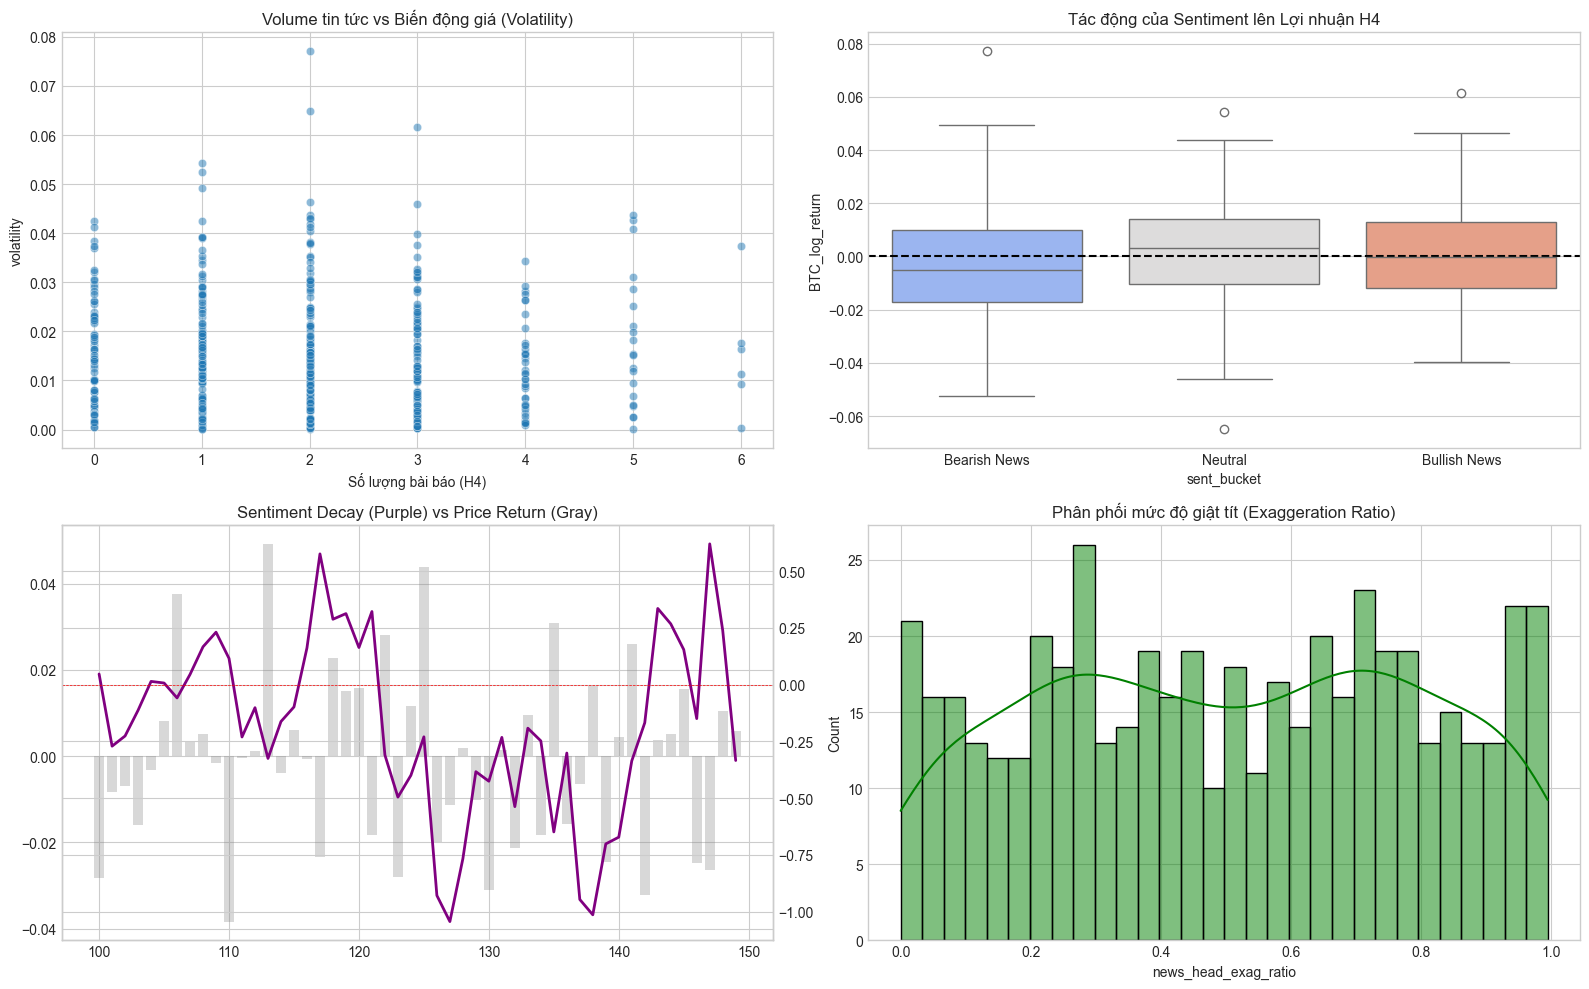

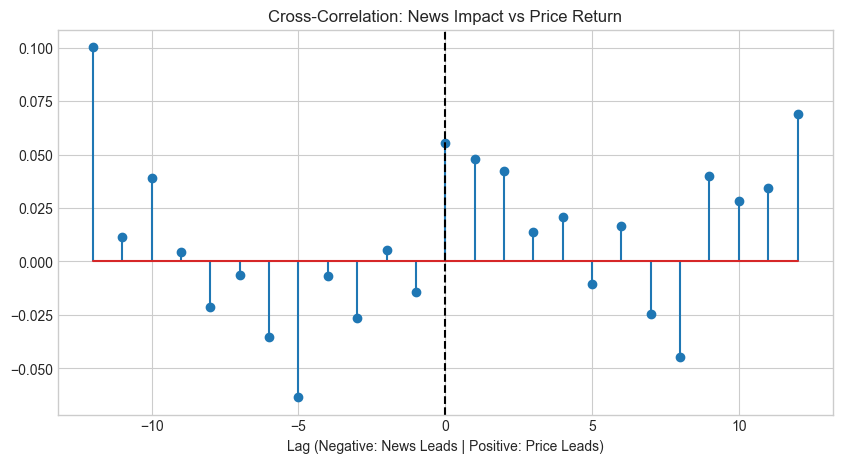

In [45]:
# %%
# ===== NEWS FEATURE ENGINEERING & EDA =====
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. DATA PREPARATION (Giả lập cấu trúc data của bạn để demo)
# Giả sử news_df là dataframe đã gộp theo khung H4 của bạn
# news_df = master_df[['timestamp', 'BTC_log_return', 'news_article_count', 'news_combined_sent_mean', ...]]

# (Trong thực tế, bạn dùng trực tiếp master_df của bạn)
# Tạo dummy data để visualize code logic
np.random.seed(42)
dates = pd.date_range(start='2023-01-01', periods=500, freq='4h')
news_df = pd.DataFrame({
    'timestamp': dates,
    'BTC_log_return': np.random.normal(0, 0.02, 500),
    'news_article_count': np.random.poisson(lam=2, size=500), # Số bài báo
    'news_combined_sent_mean': np.random.uniform(-1, 1, 500), # Sentiment (-1 Bear, 1 Bull)
    'news_head_exag_ratio': np.random.uniform(0, 1, 500) # Độ giật tít
})

# Fix Zero logic: Nếu article_count = 0, sent_mean phải = 0 (Neutral impact)
news_df.loc[news_df['news_article_count'] == 0, 'news_combined_sent_mean'] = 0
news_df['has_news'] = (news_df['news_article_count'] > 0).astype(int)

# %%
# ===== ADVANCED FEATURE ENGINEERING =====

# 1. SENTIMENT MOMENTUM (Weighted by Volume)
# Ý tưởng: Tin tức càng nhiều, Sentiment càng đáng tin và tác động mạnh.
# Interaction Feature: Sentiment * log(Volume + 1)
news_df['news_impact_score'] = news_df['news_combined_sent_mean'] * np.log1p(news_df['news_article_count'])

# 2. TIME DECAY SENTIMENT (Hiệu ứng dư âm)
# Tin tức không chết ngay. Nó ngấm dần. Dùng Exponential Moving Average (EMA).
# alpha càng nhỏ, tin tức cũ càng ảnh hưởng lâu.
news_df['news_sentiment_decay_6h']  = news_df['news_impact_score'].ewm(span=3, adjust=False).mean() # Nhanh
news_df['news_sentiment_decay_24h'] = news_df['news_impact_score'].ewm(span=6, adjust=False).mean() # Chậm

# 3. SENTIMENT SHOCK (Delta)
# Sự thay đổi đột ngột của tâm lý đám đông
news_df['news_sentiment_shock'] = news_df['news_impact_score'].diff()

# 4. CONTRARIAN INDICATOR (Chỉ báo đi ngược đám đông)
# Khi tin tức quá cực đoan (FOMO tột độ hoặc FUD tột độ) -> Dễ đảo chiều.
# Ta dùng bình phương hoặc trị tuyệt đối để đo "Độ nóng".
news_df['news_euphoria_level'] = news_df['news_impact_score'] ** 2

# %%
# ===== EDA: VISUALIZE RELATIONSHIP WITH PRICE =====

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Visual 1: News Volume vs Volatility
# Giả thuyết: Càng nhiều tin, giá càng biến động mạnh (bất kể chiều nào)
news_df['volatility'] = news_df['BTC_log_return'].abs()
sns.scatterplot(data=news_df, x='news_article_count', y='volatility', ax=axes[0,0], alpha=0.5)
axes[0,0].set_title('Volume tin tức vs Biến động giá (Volatility)')
axes[0,0].set_xlabel('Số lượng bài báo (H4)')

# Visual 2: Sentiment Buckets vs Return
# Chia Sentiment thành 3 nhóm: Bearish, Neutral, Bullish
news_df['sent_bucket'] = pd.cut(news_df['news_combined_sent_mean'], 
                                bins=[-1, -0.3, 0.3, 1], 
                                labels=['Bearish News', 'Neutral', 'Bullish News'])

sns.boxplot(data=news_df, x='sent_bucket', y='BTC_log_return', ax=axes[0,1], palette='coolwarm')
axes[0,1].set_title('Tác động của Sentiment lên Lợi nhuận H4')
axes[0,1].axhline(0, color='black', ls='--')

# Visual 3: Time Decay Effectiveness
# So sánh Sentiment thô và Sentiment có Decay với giá
# (Chỉ lấy 1 đoạn ngắn để dễ nhìn)
subset = news_df.iloc[100:150]
ax3 = axes[1,0]
ax3.bar(subset.index, subset['BTC_log_return'], color='gray', alpha=0.3, label='Price Return')
ax3_twin = ax3.twinx()
ax3_twin.plot(subset.index, subset['news_sentiment_decay_6h'], color='purple', lw=2, label='Sentiment Decay (Trend)')
ax3.set_title('Sentiment Decay (Purple) vs Price Return (Gray)')
ax3_twin.axhline(0, color='red', ls='--', lw=0.5)

# Visual 4: Exaggeration (Clickbait) Analysis
# Giả thuyết: Tin giật tít (Exag cao) thường không tạo ra biến động bền vững
sns.histplot(data=news_df, x='news_head_exag_ratio', bins=30, kde=True, ax=axes[1,1], color='green')
axes[1,1].set_title('Phân phối mức độ giật tít (Exaggeration Ratio)')

plt.tight_layout()
plt.show()

# %%
# ===== STATISTICAL VALIDATION (Lag Correlation) =====
# Tin tức đi trước hay Giá đi trước?
import matplotlib.pyplot as plt

def plot_cross_correlation(x, y, ax, title):
    lags = np.arange(-12, 13) # +/- 48 hours
    corrs = [x.corr(y.shift(l)) for l in lags]
    ax.stem(lags, corrs)
    ax.set_title(title)
    ax.set_xlabel('Lag (Negative: News Leads | Positive: Price Leads)')
    ax.axvline(0, color='k', linestyle='--')

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
plot_cross_correlation(news_df['news_impact_score'], news_df['BTC_log_return'], ax, 'Cross-Correlation: News Impact vs Price Return')
plt.show()

✅ Đã tạo xong các feature nâng cao: news_impact_score, news_sentiment_decay_6h, news_sentiment_shock
✅ Tất cả các cột đều hợp lệ.
Dataset sẵn sàng để test. Shape: (17055, 11)
--- Đang chạy đánh giá từng feature... ---


/Users/phatvu/miniconda3/lib/python3.10/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/phatvu/miniconda3/lib/python3.10/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/phatvu/miniconda3/lib/python3.10/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/phatvu/miniconda3/lib/python3.10/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/phatvu/miniconda3/lib/python3.10/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/phatvu/miniconda3/lib/python3.10/site-packages/statsmodels/tsa/stattools.


🏆 KẾT QUẢ XẾP HẠNG FEATURE NEWS:
                Feature  Mutual_Info  Causal_Pass  IC_Spearman
news_sentiment_decay_6h      0.00807        False     -0.01382
       news_p_bull_mean      0.00401         True     -0.00113
   news_sentiment_shock      0.00294         True      0.01106
news_combined_sent_mean      0.00191        False     -0.00012
 news_combined_sent_std      0.00093        False     -0.00074
   news_head_exag_ratio      0.00019        False     -0.00373
       news_is_conflict      0.00009        False     -0.00138
      news_impact_score      0.00002        False      0.00015
     news_article_count      0.00000        False     -0.00217


/Users/phatvu/miniconda3/lib/python3.10/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/var/folders/h3/4_pq_7pd3pq2286xkp78c1480000gn/T/ipykernel_32734/568279367.py:109: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_results, x='Mutual_Info', y='Feature', palette='viridis')


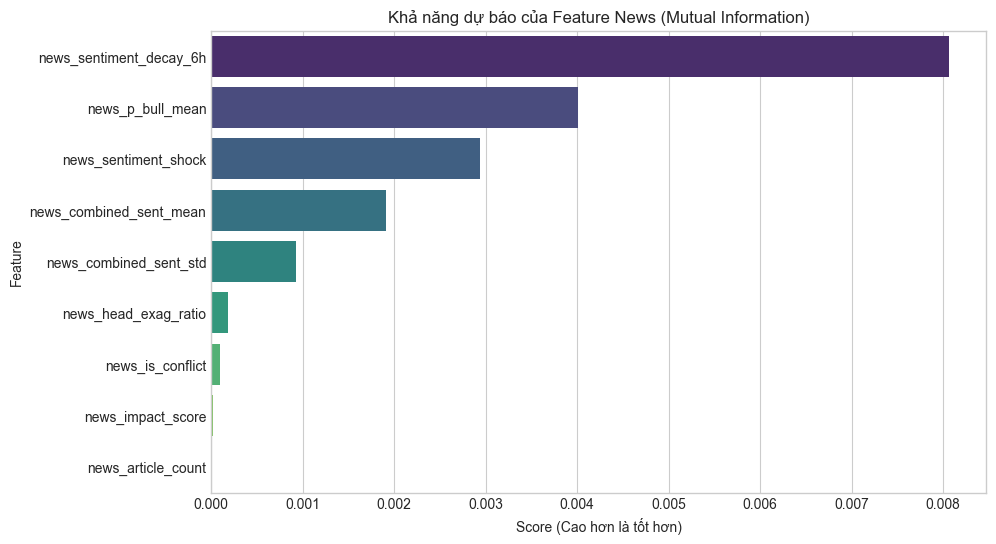

In [46]:
# %%
# ===== BƯỚC 1: TẠO FEATURE MỚI TRÊN MASTER_DF =====
# Đảm bảo master_df là biến chứa dữ liệu gốc của bạn
# Fill NaN cho các cột News nếu cần (để tránh lỗi tính toán)
news_cols_to_fill = ['news_combined_sent_mean', 'news_article_count']
master_df[news_cols_to_fill] = master_df[news_cols_to_fill].fillna(0)

# 1. Interaction: Sentiment * Volume (Impact Score)
# Dùng log(count + 1) để giảm tác động của các outlier volume quá lớn
master_df['news_impact_score'] = master_df['news_combined_sent_mean'] * np.log1p(master_df['news_article_count'])

# 2. Time Decay (Dư âm tin tức)
# Span=3 tương đương 12h (vì data khung 4H)
master_df['news_sentiment_decay_6h'] = master_df['news_impact_score'].ewm(span=3, adjust=False).mean()

# 3. Sentiment Shock (Delta)
master_df['news_sentiment_shock'] = master_df['news_impact_score'].diff()

print("✅ Đã tạo xong các feature nâng cao: news_impact_score, news_sentiment_decay_6h, news_sentiment_shock")

# %%
# ===== BƯỚC 2: CHUẨN BỊ LIST FEATURE ĐỂ TEST =====

# Danh sách TẤT CẢ các feature bạn muốn kiểm tra (Gốc + Mới tạo)
candidate_features = [
    # --- Feature Gốc (Original) ---
    'news_article_count', 
    'news_combined_sent_mean', 
    'news_combined_sent_std',      # Cột gây lỗi cũ
    'news_head_exag_ratio', 
    'news_p_bull_mean',            # Cột gây lỗi cũ
    'news_is_conflict',
    
    # --- Feature Mới (Advanced) ---
    'news_impact_score', 
    'news_sentiment_decay_6h', 
    'news_sentiment_shock'
]

# --- QUAN TRỌNG: Lọc chỉ lấy các cột THỰC SỰ TỒN TẠI trong master_df ---
# Đây là bước sửa lỗi KeyError triệt để
available_features = [col for col in candidate_features if col in master_df.columns]
missing_features = [col for col in candidate_features if col not in master_df.columns]

if missing_features:
    print(f"⚠️ Cảnh báo: Các cột sau không tìm thấy và sẽ bị bỏ qua: {missing_features}")
else:
    print("✅ Tất cả các cột đều hợp lệ.")

# Tạo dataset để test (bao gồm Target)
# Lưu ý: Target là Return của cây nến TIẾP THEO (t+1)
df_eval = master_df[available_features + ['BTC_log_return']].copy()
df_eval['TARGET_NEXT_RETURN'] = df_eval['BTC_log_return'].shift(-1)
df_eval.dropna(inplace=True)

print(f"Dataset sẵn sàng để test. Shape: {df_eval.shape}")

# %%
# ===== BƯỚC 3: CHẠY KIỂM ĐỊNH (GRANGER & MUTUAL INFO) =====
from statsmodels.tsa.stattools import grangercausalitytests
from sklearn.feature_selection import mutual_info_regression
from scipy.stats import spearmanr
import pandas as pd

results = []

print("--- Đang chạy đánh giá từng feature... ---")

for feat in available_features:
    try:
        # 1. Granger Causality (Kiểm tra nhân quả Lag 1)
        # Input shape: [Target, Predictor]
        gc_data = df_eval[['TARGET_NEXT_RETURN', feat]].values
        # maxlag=1 vì tin tức tác động nhanh
        gc_res = grangercausalitytests(gc_data, maxlag=[1], verbose=False)
        p_val_granger = gc_res[1][0]['ssr_chi2test'][1]
        
        # 2. Mutual Information (Phi tuyến tính)
        mi_score = mutual_info_regression(df_eval[[feat]], df_eval['TARGET_NEXT_RETURN'], random_state=42)[0]
        
        # 3. Spearman Correlation (Tuyến tính/Hướng)
        corr, _ = spearmanr(df_eval[feat], df_eval['TARGET_NEXT_RETURN'])
        
        results.append({
            'Feature': feat,
            'Mutual_Info': mi_score,      # Càng cao càng tốt
            'Granger_P_Val': p_val_granger, # < 0.05 là Tốt
            'IC_Spearman': corr           # Độ mạnh tương quan
        })
        
    except Exception as e:
        print(f"Lỗi khi test feature '{feat}': {e}")

# Tổng hợp kết quả
df_results = pd.DataFrame(results)
df_results['Causal_Pass'] = df_results['Granger_P_Val'] < 0.05

# Sắp xếp theo MI (Mutual Info) để chọn ra feature mạnh nhất
df_results = df_results.sort_values(by='Mutual_Info', ascending=False)

print("\n🏆 KẾT QUẢ XẾP HẠNG FEATURE NEWS:")
print(df_results[['Feature', 'Mutual_Info', 'Causal_Pass', 'IC_Spearman']].to_string(index=False))

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.barplot(data=df_results, x='Mutual_Info', y='Feature', palette='viridis')
plt.title('Khả năng dự báo của Feature News (Mutual Information)')
plt.xlabel('Score (Cao hơn là tốt hơn)')
plt.show()



## Sentiment index

--- Preparing Sentiment Data ---
Data ready. Shape: (17057, 5)
--- Engineering Sentiment Features ---
Features created: fng_change, fng_divergence, is_extreme_fear/greed


/var/folders/h3/4_pq_7pd3pq2286xkp78c1480000gn/T/ipykernel_32734/2949034093.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sent_df, x='fng_bucket', y='next_return', palette='RdYlGn', ax=axes[1], errorbar=None)


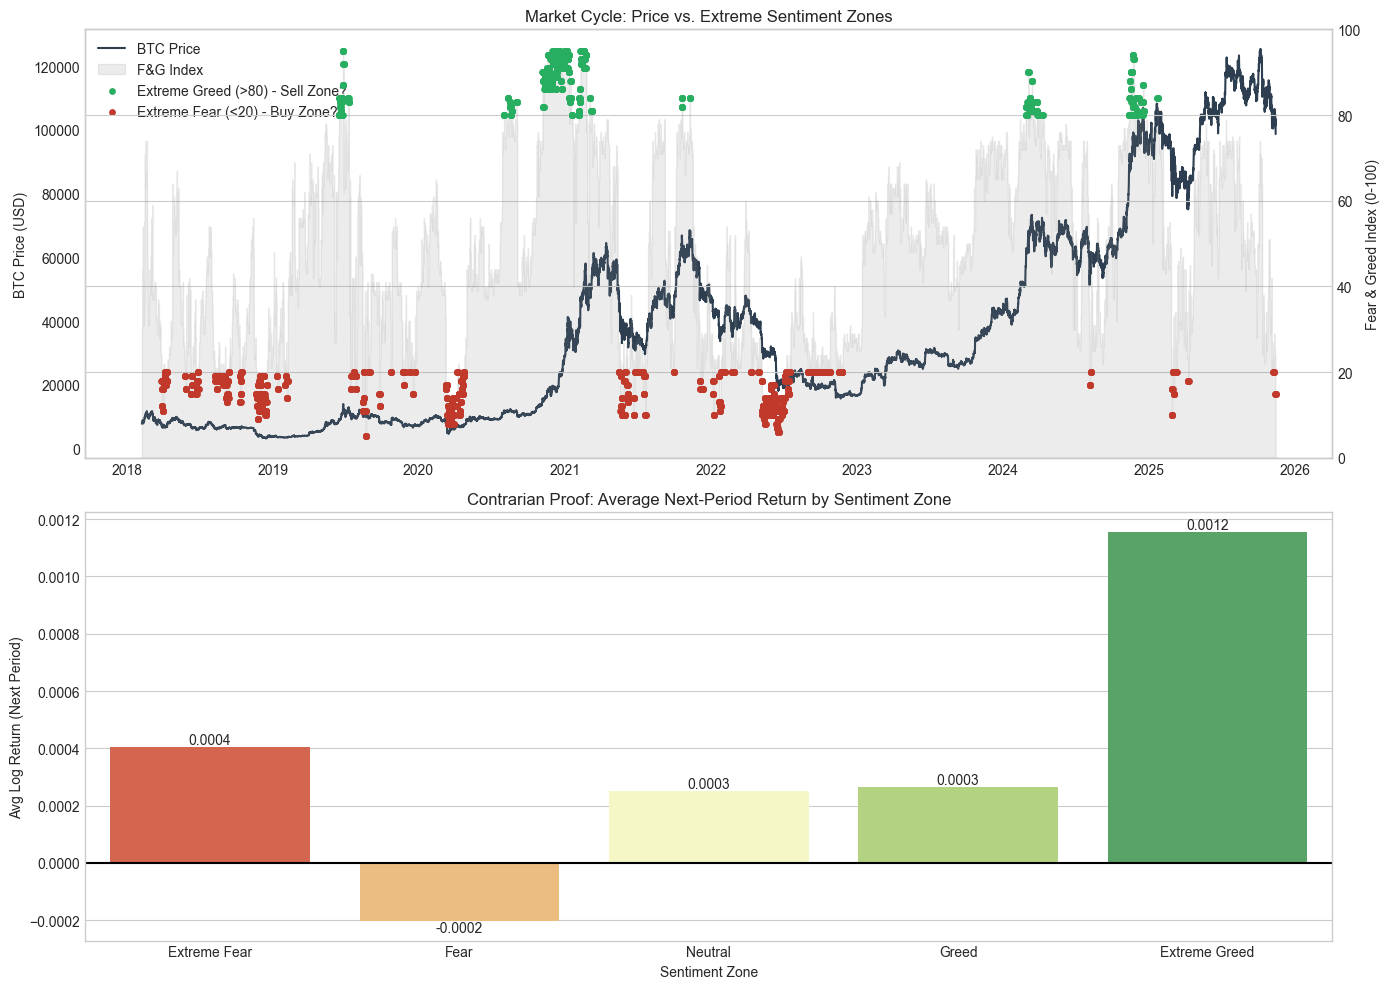


--- Validation Results ---
ADF Test | fng_change          : p-value=0.00000 -> ✅ PASS
ADF Test | fng_divergence      : p-value=0.00000 -> ✅ PASS

Correlation with Next Return:
fng_change       0.01091
fng_divergence   0.00790
Name: next_return, dtype: float64


In [49]:
# %%
# ===== STANDARD LIBRARY & SETUP =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda x: '%.5f' % x)

# %%
# ===== 1. DATA PREPARATION =====
print("--- Preparing Sentiment Data ---")

# Chọn các cột cần thiết từ master_df
sent_cols = ['sentiment_index_value', 'sentiment_index_classification']

# Tạo dataframe phân tích riêng (đảm bảo không ảnh hưởng master_df gốc khi test)
# Thêm copy() để tránh SettingWithCopyWarning
sent_df = master_df[['timestamp', 'BTC_close', 'BTC_log_return'] + sent_cols].copy()

# Loại bỏ các dòng thiếu dữ liệu (nếu có)
sent_df.dropna(inplace=True)

print(f"Data ready. Shape: {sent_df.shape}")

# %%
# ===== 2. FEATURE ENGINEERING: SENTIMENT INDEX =====
print("--- Engineering Sentiment Features ---")

# 2.1. Encoding Classification (Chuyển Text sang Số)
mapping = {
    'Extreme Fear': 0, 
    'Fear': 1, 
    'Neutral': 2, 
    'Greed': 3, 
    'Extreme Greed': 4
}
# Map và fillna bằng 2 (Neutral) nếu có giá trị lạ
sent_df['sentiment_class_encoded'] = sent_df['sentiment_index_classification'].map(mapping).fillna(2)

# 2.2. Momentum (Change)
# Đo lường sự thay đổi tâm lý so với phiên trước
sent_df['fng_change'] = sent_df['sentiment_index_value'].diff()

# 2.3. Divergence (Sự lệch chuẩn)
# So sánh tâm lý hiện tại với trung bình 7 ngày (7 * 6 nến 4H = 42 chu kỳ)
window_7d = 7 * 6 
sent_df['fng_ma7'] = sent_df['sentiment_index_value'].rolling(window_7d).mean()
sent_df['fng_divergence'] = sent_df['sentiment_index_value'] - sent_df['fng_ma7']

# 2.4. Contrarian Flags (Vùng Đảo Chiều Cực Đoan)
sent_df['is_extreme_fear'] = (sent_df['sentiment_index_value'] <= 20).astype(int)
sent_df['is_extreme_greed'] = (sent_df['sentiment_index_value'] >= 80).astype(int)

# 2.5. Tạo Bucket cho Visualization (Phân nhóm)
sent_df['fng_bucket'] = pd.cut(sent_df['sentiment_index_value'], 
                               bins=[0, 20, 45, 55, 80, 100],
                               labels=['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed'])

# 2.6. Target Prep (Next Period Return)
# Để kiểm tra xem mua ở vùng Fear có lãi vào ngày mai không?
sent_df['next_return'] = sent_df['BTC_log_return'].shift(-1)

# Clean up NaN do diff/rolling tạo ra
sent_df.dropna(inplace=True)

print("Features created: fng_change, fng_divergence, is_extreme_fear/greed")

# %%
# ===== 3. EDA VISUALIZATION (FIXED) =====
# Lỗi cũ do sharex=True giữa Time-Series và Categorical. Đã sửa sharex=False.

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=False) 

# --- PLOT 1: BTC Price vs Sentiment Cycle (Time Series) ---
# Vẽ giá BTC
axes[0].plot(sent_df['timestamp'], sent_df['BTC_close'], color='#2c3e50', lw=1.5, label='BTC Price')
axes[0].set_title('Market Cycle: Price vs. Extreme Sentiment Zones')
axes[0].set_ylabel('BTC Price (USD)')
axes[0].grid(False) # Tắt grid trục giá cho đỡ rối

# Vẽ Sentiment Index trục phải
ax0_twin = axes[0].twinx()
ax0_twin.fill_between(sent_df['timestamp'], 0, sent_df['sentiment_index_value'], color='gray', alpha=0.15, label='F&G Index')

# Highlight điểm cực đoan (Scatter plot)
# Lọc data để vẽ
greed_pts = sent_df[sent_df['is_extreme_greed'] == 1]
fear_pts = sent_df[sent_df['is_extreme_fear'] == 1]

if not greed_pts.empty:
    ax0_twin.scatter(greed_pts['timestamp'], greed_pts['sentiment_index_value'], 
                     color='#27ae60', s=15, label='Extreme Greed (>80) - Sell Zone?')

if not fear_pts.empty:
    ax0_twin.scatter(fear_pts['timestamp'], fear_pts['sentiment_index_value'], 
                     color='#c0392b', s=15, label='Extreme Fear (<20) - Buy Zone?')

ax0_twin.set_ylabel('Fear & Greed Index (0-100)')
ax0_twin.set_ylim(0, 100)

# Gom Legend lại cho đẹp
lines1, labels1 = axes[0].get_legend_handles_labels()
lines2, labels2 = ax0_twin.get_legend_handles_labels()
axes[0].legend(lines1 + lines2, labels1 + labels2, loc='upper left')


# --- PLOT 2: Return Distribution by Sentiment Zone (Categorical Bar) ---
# Dùng Barplot để trả lời: "Mua khi đám đông sợ hãi có lời hơn không?"
sns.barplot(data=sent_df, x='fng_bucket', y='next_return', palette='RdYlGn', ax=axes[1], errorbar=None)

axes[1].axhline(0, color='black', lw=1.5)
axes[1].set_title('Contrarian Proof: Average Next-Period Return by Sentiment Zone')
axes[1].set_ylabel('Avg Log Return (Next Period)')
axes[1].set_xlabel('Sentiment Zone')

# Thêm giá trị text lên cột
for i, container in enumerate(axes[1].containers):
    axes[1].bar_label(container, fmt='%.4f')

plt.tight_layout()
plt.show()

# %%
# ===== 4. STATISTICAL VALIDATION =====
print("\n--- Validation Results ---")

# 4.1 Stationarity Check
# F&G Index bị chặn 0-100 nên thường là stationary, nhưng kiểm tra feature phái sinh
cols_check = ['fng_change', 'fng_divergence']
for col in cols_check:
    res = adfuller(sent_df[col])
    p_val = res[1]
    status = "✅ PASS" if p_val < 0.05 else "❌ FAIL"
    print(f"ADF Test | {col: <20}: p-value={p_val:.5f} -> {status}")

# 4.2 Correlation Analysis
# Kiểm tra tương quan giữa sự thay đổi tâm lý và lợi nhuận tương lai
corr_val = sent_df[['next_return', 'fng_change', 'fng_divergence']].corr()['next_return']
print("\nCorrelation with Next Return:")
print(corr_val.drop('next_return'))